Position 1 (item as item1) logits:
  Mean: [ 0.082 -0.16   0.014 -0.228 -0.094  0.095 -0.198 -0.443]
  Std:  [0.205 0.222 0.207 0.302 0.176 0.214 0.187 0.258]
  Items: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Position 2 (item as item2) logits:
  Mean: [-0.444 -0.216  0.086 -0.088 -0.223  0.022 -0.151  0.08 ]
  Std:  [0.26  0.203 0.221 0.17  0.302 0.206 0.208 0.198]
  Items: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']



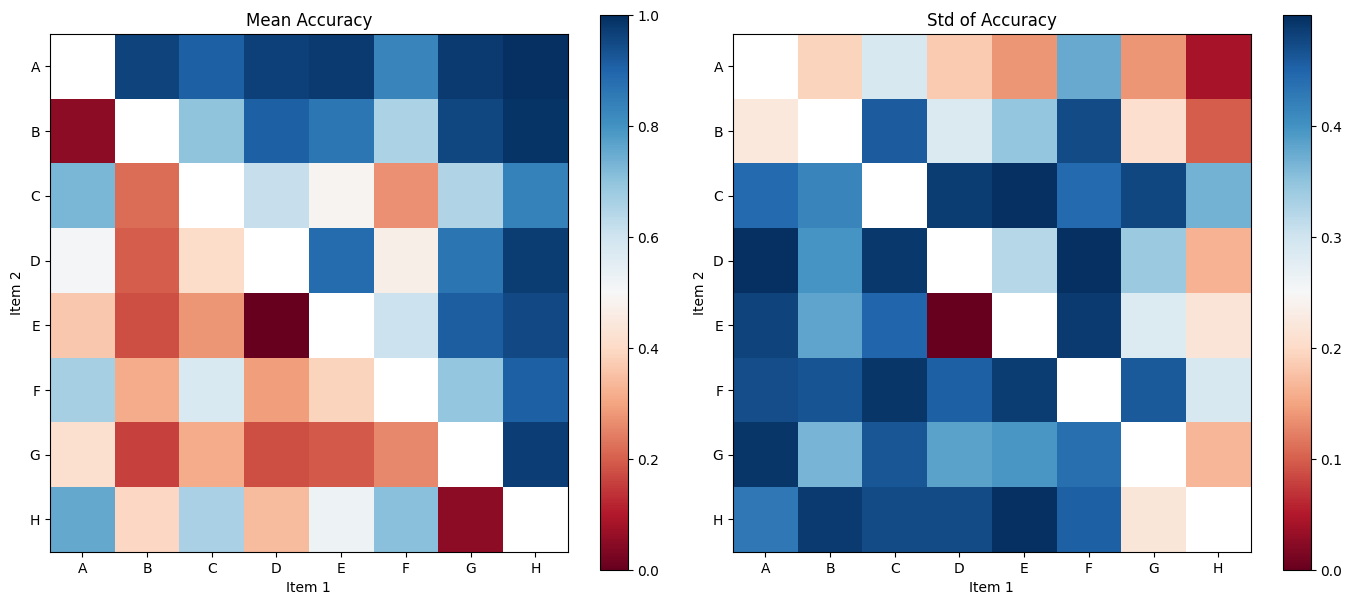

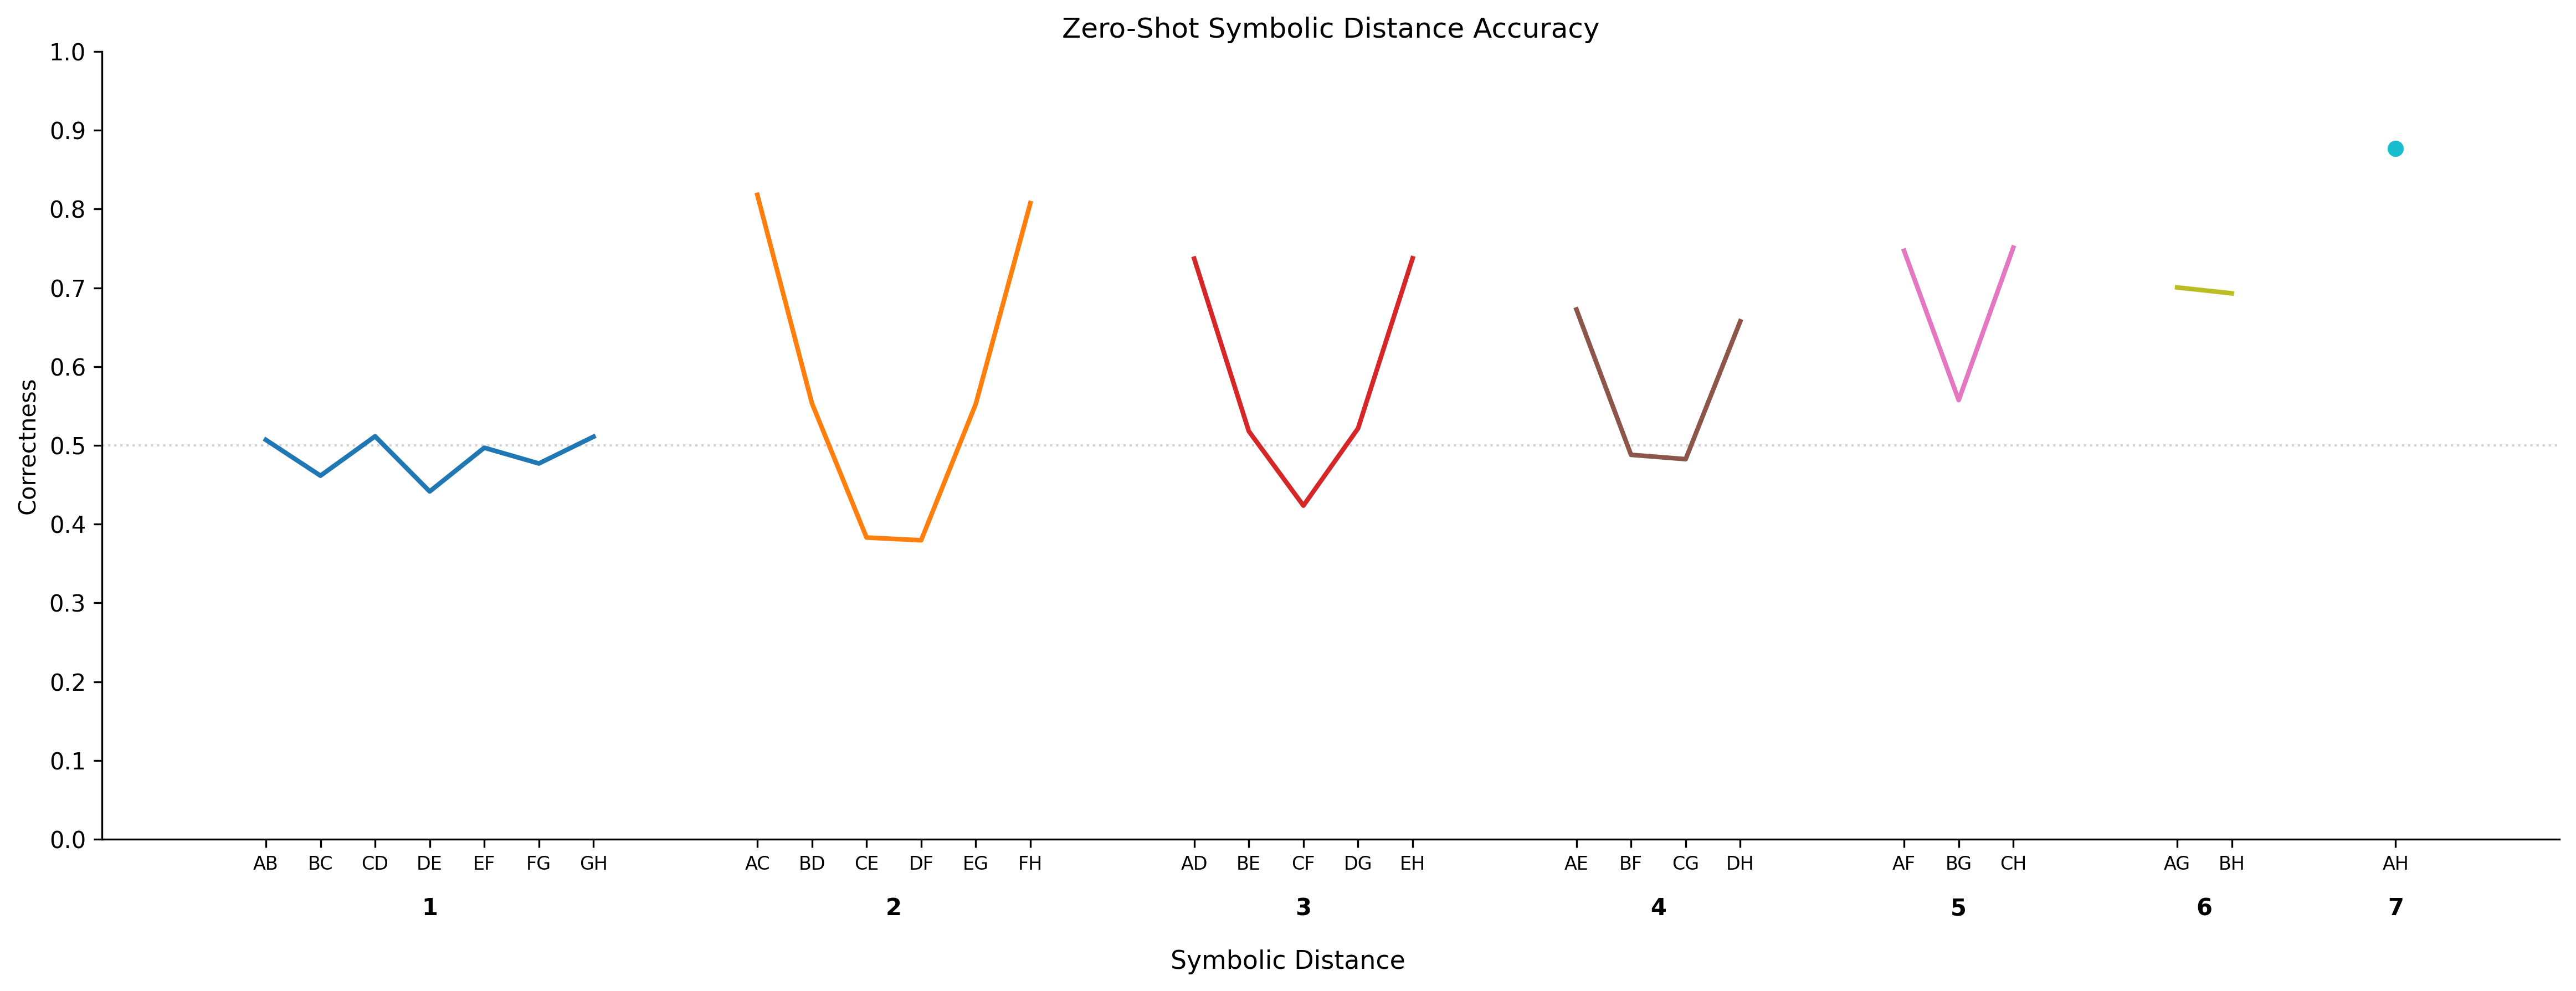

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

NM_LINE_A = 1.1
NM_LINE_B = -1.0
NBEPISODES = 1000
NEG_NM_SCALAR = -NM_LINE_A-NM_LINE_B
POS_NM_SCALAR = NM_LINE_A-NM_LINE_B
NUM_TRAIN_TRIALS = 20
N_ITEMS = 8
LIST_LINKING = True

# Item representations: standard basis vectors in R^8
items = np.eye(N_ITEMS)

# Innate weights
# Layer 1: [[I, -I], [-I, I]] (16x16, fixed)
I_mat = np.eye(N_ITEMS)
W1_innate = np.block([[I_mat, -I_mat], [I_mat, -I_mat]])

# Layer 2: ones(16) (fixed)
W2_innate = np.ones(2 * N_ITEMS)

# All ordered pairs (i, j) where i != j for testing
test_pairs = [(i, j) for i in range(N_ITEMS) for j in range(N_ITEMS) if i != j]
n_test = len(test_pairs)

# Track accuracy per pair across episodes
pair_results = np.zeros((NBEPISODES, n_test))

# Accumulate per-item logit vectors across episodes
pos1_logits_all = np.zeros((NBEPISODES, N_ITEMS))  # item in pos1, logit = W2 @ W1 @ [e_i; 0]
pos2_logits_all = np.zeros((NBEPISODES, N_ITEMS))  # item in pos2, logit = W2 @ W1 @ [0; e_j]

for ep in range(NBEPISODES):
    # Reset plastic weights
    P1 = np.zeros((2 * N_ITEMS, 2 * N_ITEMS))
    P2 = np.zeros(2 * N_ITEMS)

    # Per-episode noise on readout to break ones symmetry
    # epsilon = 0
    epsilon = np.random.randn(2 * N_ITEMS) * 0.05
    W2_ep = W2_innate + epsilon

    # Generate training trials
    train_trials = []
    if LIST_LINKING:
        # List 1: items 0-3 (A-D), adjacent pairs from (0,1),(1,2),(2,3)
        for _ in range(25):
            pos1 = np.random.randint(0, 3)  # 0,1,2
            pos2 = pos1 + 1
            if np.random.rand() < 0.5:
                train_trials.append((pos1, pos2))
            else:
                train_trials.append((pos2, pos1))
        # List 2: items 4-7 (E-H), adjacent pairs from (4,5),(5,6),(6,7)
        for _ in range(25):
            pos1 = np.random.randint(4, 7)  # 4,5,6
            pos2 = pos1 + 1
            if np.random.rand() < 0.5:
                train_trials.append((pos1, pos2))
            else:
                train_trials.append((pos2, pos1))
        # Linking pair: D-E (3,4), shown 4 times
        for _ in range(3):
            if np.random.rand() < 0.5:
                train_trials.append((3, 4))
            else:
                train_trials.append((4, 3))
    else:
        for _ in range(NUM_TRAIN_TRIALS):
            pos1 = np.random.randint(N_ITEMS - 1)
            pos2 = pos1 + 1
            if np.random.rand() < 0.5:
                train_trials.append((pos1, pos2))
            else:
                train_trials.append((pos2, pos1))

    # Training
    for (i, j) in train_trials:
        inp = np.concatenate([items[i], items[j]])  # [e_i; e_j] in R^16
        W1 = W1_innate + P1
        hidden = W1 @ inp  # no activation
        W2 = W2_ep + P2
        output = W2 @ hidden  # scalar

        choice = 1 if output > 0 else 0
        correct = 1 if i < j else 0  # lower index = higher rank
        reward = 1 if choice == correct else -1
        if reward == -1:
            # nm = NEG_NM_SCALAR
            nm = -0.3
        else:
            # nm = POS_NM_SCALAR
            nm = 0

        # Hebbian updates
        P1 += nm * np.outer(hidden, inp)
        P2 += nm * (output+1) * hidden

    # Testing: all 56 ordered pairs
    W1 = W1_innate + P1
    W2 = W2_ep + P2
    for t, (i, j) in enumerate(test_pairs):
        inp = np.concatenate([items[i], items[j]])
        hidden = W1 @ inp
        output = W2 @ hidden
        choice = 1 if output > 0 else 0
        correct = 1 if i < j else 0
        pair_results[ep, t] = 1 if choice == correct else 0

    # Individual item logits: pass each item alone in pos1 or pos2
    for k in range(N_ITEMS):
        # Position 1: [e_k; 0]
        inp_pos1 = np.concatenate([items[k], np.zeros(N_ITEMS)])
        hidden_pos1 = W1 @ inp_pos1
        pos1_logits_all[ep, k] = W2 @ hidden_pos1

        # Position 2: [0; e_k]
        inp_pos2 = np.concatenate([np.zeros(N_ITEMS), items[k]])
        hidden_pos2 = W1 @ inp_pos2
        pos2_logits_all[ep, k] = W2 @ hidden_pos2

# Print individual item logit vectors (mean and std across episodes)
item_labels = [chr(ord('A') + k) for k in range(N_ITEMS)]
print("Position 1 (item as item1) logits:")
print(f"  Mean: {np.round(np.mean(pos1_logits_all, axis=0), 3)}")
print(f"  Std:  {np.round(np.std(pos1_logits_all, axis=0), 3)}")
print(f"  Items: {item_labels}")
print()
print("Position 2 (item as item2) logits:")
print(f"  Mean: {np.round(np.mean(pos2_logits_all, axis=0), 3)}")
print(f"  Std:  {np.round(np.std(pos2_logits_all, axis=0), 3)}")
print(f"  Items: {item_labels}")
print()

# Compute mean and std accuracy per pair
mean_acc = np.mean(pair_results, axis=0)
std_acc = np.std(pair_results, axis=0)

# Build heatmaps (item1 on x-axis, item2 on y-axis)
mean_grid = np.full((N_ITEMS, N_ITEMS), np.nan)
std_grid = np.full((N_ITEMS, N_ITEMS), np.nan)
for t, (i, j) in enumerate(test_pairs):
    mean_grid[j, i] = mean_acc[t]  # x=item1(i), y=item2(j)
    std_grid[j, i] = std_acc[t]

labels = [chr(ord('A') + k) for k in range(N_ITEMS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(mean_grid, vmin=0, vmax=1, cmap='RdBu', origin='upper')
axes[0].set_xticks(range(N_ITEMS))
axes[0].set_xticklabels(labels)
axes[0].set_yticks(range(N_ITEMS))
axes[0].set_yticklabels(labels)
axes[0].set_xlabel('Item 1')
axes[0].set_ylabel('Item 2')
axes[0].set_title('Mean Accuracy')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(std_grid, vmin=0, cmap='RdBu', origin='upper')
axes[1].set_xticks(range(N_ITEMS))
axes[1].set_xticklabels(labels)
axes[1].set_yticks(range(N_ITEMS))
axes[1].set_yticklabels(labels)
axes[1].set_xlabel('Item 1')
axes[1].set_ylabel('Item 2')
axes[1].set_title('Std of Accuracy')
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# Symbolic distance plot (matching zero_shot_symbolic_distance_plot style)
# Build zero_shot_trials dict: (i,j) with i<j -> list of correctness across episodes
# Average both orderings (i,j) and (j,i) into the canonical (min,max) pair
zero_shot_trials = {}
for t, (i, j) in enumerate(test_pairs):
    key = (min(i, j), max(i, j))
    if key not in zero_shot_trials:
        zero_shot_trials[key] = []
    zero_shot_trials[key].extend(pair_results[:, t].tolist())

pair_avg = {k: np.mean(v) for k, v in zero_shot_trials.items()}

# Organize by symbolic distance
correctness_by_sd = {sd: {} for sd in range(1, N_ITEMS)}
for (i, j), avg in pair_avg.items():
    sd = abs(j - i)
    correctness_by_sd[sd][(i, j)] = avg

fixed_sd_space = 1.5
fixed_pair_space = 0.5
num_sd = N_ITEMS - 1
total_pairs = sum(len(v) for v in correctness_by_sd.values())
total_width = (num_sd + 1) * fixed_sd_space + total_pairs * fixed_pair_space
fig_width = max(8, total_width * 0.6)

pair_label_map = {(i, j): chr(i + ord('A')) + chr(j + ord('A'))
                  for i in range(N_ITEMS) for j in range(i + 1, N_ITEMS)}

fig, ax = plt.subplots(figsize=(fig_width, 6), dpi=300)
ax.axhline(y=0.5, color='lightgray', linestyle=':', linewidth=1, zorder=0)
colors = plt.cm.tab10(np.linspace(0, 1, num_sd))

all_x = []
all_labels = []
sd_centers = []
sd_labels = []
current_x = fixed_sd_space

for sd_idx, sd in enumerate(range(1, N_ITEMS)):
    pairs = correctness_by_sd[sd]
    sorted_pairs = sorted(pairs.keys(), key=lambda x: x[0])
    if not sorted_pairs:
        continue

    x_positions = []
    means = []
    p_labels = []
    for pi, pair in enumerate(sorted_pairs):
        x_pos = current_x + pi * fixed_pair_space
        x_positions.append(x_pos)
        means.append(pairs[pair])
        p_labels.append(pair_label_map.get(pair, f"{pair[0]}{pair[1]}"))

    x_positions = np.array(x_positions)
    means = np.array(means)
    color = colors[sd_idx]
    marker = 'o' if sd == N_ITEMS - 1 else ''
    ax.plot(x_positions, means, color=color, linewidth=2, marker=marker, markersize=6, label=f'SD {sd}')

    all_x.extend(x_positions.tolist())
    all_labels.extend(p_labels)
    sd_centers.append((x_positions[0] + x_positions[-1]) / 2)
    sd_labels.append(str(sd))
    current_x = x_positions[-1] + fixed_sd_space

ax.set_xticks(all_x)
ax.set_xticklabels(all_labels, fontsize=8)
ax2 = ax.secondary_xaxis('bottom')
ax2.set_xticks(sd_centers)
ax2.set_xticklabels(sd_labels, fontsize=10, fontweight='bold')
ax2.tick_params(length=0, pad=25)
ax2.spines['bottom'].set_visible(False)

ax.set_title('Zero-Shot Symbolic Distance Accuracy')
ax.set_ylabel('Correctness')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.1))
fig.text(0.5, 0.02, 'Symbolic Distance', ha='center', fontsize=11)
ax.set_xlim(0, current_x)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def run_1layer(nm_pos=0.0, nm_neg=-0.2, alpha=0.01, n_episodes=1000, item_dim=15,
               n_items=8, num_train_trials=20, list_linking=False, list_linking_within_list_trials=10,
               linking_pair_trials=4, max_cos_sim=None):
    """1-Layer Readout-Only Model.
    output = W_readout @ [e_i; e_j] + alpha * P @ [e_i; e_j]
    W_readout = [1,...,1, -1,...,-1], frozen. Items: random +-1 vectors, resampled each episode.
    If max_cos_sim is set, resample items until all pairwise cosine similarities are below that threshold.
    """
    W_readout = np.concatenate([np.ones(item_dim), -np.ones(item_dim)])

    test_pairs = [(i, j) for i in range(n_items) for j in range(n_items) if i != j]
    n_test = len(test_pairs)

    pair_results = np.zeros((n_episodes, n_test))
    pos1_logits_all = np.zeros((n_episodes, n_items))
    pos2_logits_all = np.zeros((n_episodes, n_items))
    resample_counts = []

    for ep in tqdm(range(n_episodes)):
        # Sample items, optionally enforcing max cosine similarity
        attempts = 0
        while True:
            items = np.sign(np.random.randn(n_items, item_dim))
            attempts += 1
            if max_cos_sim is None:
                break
            norms = np.linalg.norm(items, axis=1, keepdims=True)
            cos_mat = (items @ items.T) / (norms @ norms.T)
            np.fill_diagonal(cos_mat, 0)
            if np.max(np.abs(cos_mat)) <= max_cos_sim:
                break
        resample_counts.append(attempts)

        P = np.zeros(2 * item_dim)

        train_trials = []
        if list_linking:
            for _ in range(list_linking_within_list_trials):
                pos1 = np.random.randint(0, 3)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))
            for _ in range(list_linking_within_list_trials):
                pos1 = np.random.randint(4, 7)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))
            for _ in range(linking_pair_trials):
                if np.random.rand() < 0.5:
                    train_trials.append((3, 4))
                else:
                    train_trials.append((4, 3))
        else:
            for _ in range(num_train_trials):
                pos1 = np.random.randint(n_items - 1)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))

        for (i, j) in train_trials:
            inp = np.concatenate([items[i], items[j]])
            output = (W_readout + alpha * P) @ inp

            choice = 1 if output > 0 else 0
            correct = 1 if i < j else 0
            reward = 1 if choice == correct else -1
            nm = nm_pos if reward == 1 else nm_neg

            P += nm * (output) * inp

        W_total = W_readout + alpha * P
        for t, (i, j) in enumerate(test_pairs):
            inp = np.concatenate([items[i], items[j]])
            output = W_total @ inp
            choice = 1 if output > 0 else 0
            correct = 1 if i < j else 0
            pair_results[ep, t] = 1 if choice == correct else 0

        for k in range(n_items):
            inp_pos1 = np.concatenate([items[k], np.zeros(item_dim)])
            pos1_logits_all[ep, k] = W_total @ inp_pos1
            inp_pos2 = np.concatenate([np.zeros(item_dim), items[k]])
            pos2_logits_all[ep, k] = W_total @ inp_pos2

    # Print
    item_labels = [chr(ord('A') + k) for k in range(n_items)]
    print(f"=== 1-Layer Readout-Only Model ===")
    print(f"nm_pos={nm_pos}, nm_neg={nm_neg}, alpha={alpha}, list_linking={list_linking}")
    if max_cos_sim is not None:
        print(f"max_cos_sim={max_cos_sim}, avg resamples={np.mean(resample_counts):.1f}, max resamples={np.max(resample_counts)}")
    print()
    print("Position 1 (item as item1) logits:")
    print(f"  Mean: {np.round(np.mean(pos1_logits_all, axis=0), 3)}")
    print(f"  Std:  {np.round(np.std(pos1_logits_all, axis=0), 3)}")
    print(f"  Items: {item_labels}")
    print()
    print("Position 2 (item as item2) logits:")
    print(f"  Mean: {np.round(np.mean(pos2_logits_all, axis=0), 3)}")
    print(f"  Std:  {np.round(np.std(pos2_logits_all, axis=0), 3)}")
    print(f"  Items: {item_labels}")
    print()

    mean_acc = np.mean(pair_results, axis=0)
    std_acc = np.std(pair_results, axis=0)

    # Heatmaps
    mean_grid = np.full((n_items, n_items), np.nan)
    std_grid = np.full((n_items, n_items), np.nan)
    for t, (i, j) in enumerate(test_pairs):
        mean_grid[j, i] = mean_acc[t]
        std_grid[j, i] = std_acc[t]

    labels = [chr(ord('A') + k) for k in range(n_items)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    im0 = axes[0].imshow(mean_grid, vmin=0, vmax=1, cmap='RdBu', origin='upper')
    axes[0].set_xticks(range(n_items)); axes[0].set_xticklabels(labels)
    axes[0].set_yticks(range(n_items)); axes[0].set_yticklabels(labels)
    axes[0].set_xlabel('Item 1'); axes[0].set_ylabel('Item 2')
    axes[0].set_title('Mean Accuracy (1-Layer)')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(std_grid, vmin=0, cmap='RdBu', origin='upper')
    axes[1].set_xticks(range(n_items)); axes[1].set_xticklabels(labels)
    axes[1].set_yticks(range(n_items)); axes[1].set_yticklabels(labels)
    axes[1].set_xlabel('Item 1'); axes[1].set_ylabel('Item 2')
    axes[1].set_title('Std of Accuracy (1-Layer)')
    fig.colorbar(im1, ax=axes[1])
    plt.tight_layout(); plt.show()

    # Symbolic distance plot
    zero_shot_trials = {}
    for t, (i, j) in enumerate(test_pairs):
        key = (min(i, j), max(i, j))
        if key not in zero_shot_trials:
            zero_shot_trials[key] = []
        zero_shot_trials[key].extend(pair_results[:, t].tolist())

    pair_avg = {k: np.mean(v) for k, v in zero_shot_trials.items()}
    correctness_by_sd = {sd: {} for sd in range(1, n_items)}
    for (i, j), avg in pair_avg.items():
        sd = abs(j - i)
        correctness_by_sd[sd][(i, j)] = avg

    fixed_sd_space = 1.5; fixed_pair_space = 0.5
    num_sd = n_items - 1
    total_pairs = sum(len(v) for v in correctness_by_sd.values())
    total_width = (num_sd + 1) * fixed_sd_space + total_pairs * fixed_pair_space
    fig_width = max(8, total_width * 0.6)
    pair_label_map = {(i, j): chr(i + ord('A')) + chr(j + ord('A'))
                      for i in range(n_items) for j in range(i + 1, n_items)}

    fig, ax = plt.subplots(figsize=(fig_width, 6), dpi=300)
    ax.axhline(y=0.5, color='lightgray', linestyle=':', linewidth=1, zorder=0)
    colors = plt.cm.tab10(np.linspace(0, 1, num_sd))
    all_x = []; all_labels = []; sd_centers = []; sd_labels = []
    current_x = fixed_sd_space

    for sd_idx, sd in enumerate(range(1, n_items)):
        pairs = correctness_by_sd[sd]
        sorted_pairs = sorted(pairs.keys(), key=lambda x: x[0])
        if not sorted_pairs:
            continue
        x_positions = []; means = []; p_labels = []
        for pi, pair in enumerate(sorted_pairs):
            x_pos = current_x + pi * fixed_pair_space
            x_positions.append(x_pos)
            means.append(pairs[pair])
            p_labels.append(pair_label_map.get(pair, f"{pair[0]}{pair[1]}"))
        x_positions = np.array(x_positions); means = np.array(means)
        color = colors[sd_idx]
        marker = 'o' if sd == n_items - 1 else ''
        ax.plot(x_positions, means, color=color, linewidth=2, marker=marker, markersize=6, label=f'SD {sd}')
        all_x.extend(x_positions.tolist()); all_labels.extend(p_labels)
        sd_centers.append((x_positions[0] + x_positions[-1]) / 2)
        sd_labels.append(str(sd))
        current_x = x_positions[-1] + fixed_sd_space

    ax.set_xticks(all_x); ax.set_xticklabels(all_labels, fontsize=8)
    ax2 = ax.secondary_xaxis('bottom')
    ax2.set_xticks(sd_centers); ax2.set_xticklabels(sd_labels, fontsize=10, fontweight='bold')
    ax2.tick_params(length=0, pad=25); ax2.spines['bottom'].set_visible(False)
    ax.set_title('Zero-Shot Symbolic Distance Accuracy (1-Layer)')
    ax.set_ylabel('Correctness'); ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    fig.text(0.5, 0.02, 'Symbolic Distance', ha='center', fontsize=11)
    ax.set_xlim(0, current_x)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.subplots_adjust(bottom=0.15); plt.show()


100%|██████████| 5000/5000 [00:01<00:00, 4752.24it/s]


=== 1-Layer Readout-Only Model ===
nm_pos=0.0, nm_neg=-7, alpha=0.01, list_linking=True
max_cos_sim=1.0, avg resamples=1.0, max resamples=1

Position 1 (item as item1) logits:
  Mean: [ 2.072  0.474 -0.431  2.853 -2.393  0.555 -0.573 -2.495]
  Std:  [3.865 3.877 3.972 3.74  3.796 3.935 3.955 3.814]
  Items: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Position 2 (item as item2) logits:
  Mean: [-2.078 -0.48   0.363 -2.846  2.422 -0.453  0.631  2.342]
  Std:  [3.906 3.898 3.914 3.756 3.827 3.953 3.949 3.86 ]
  Items: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']



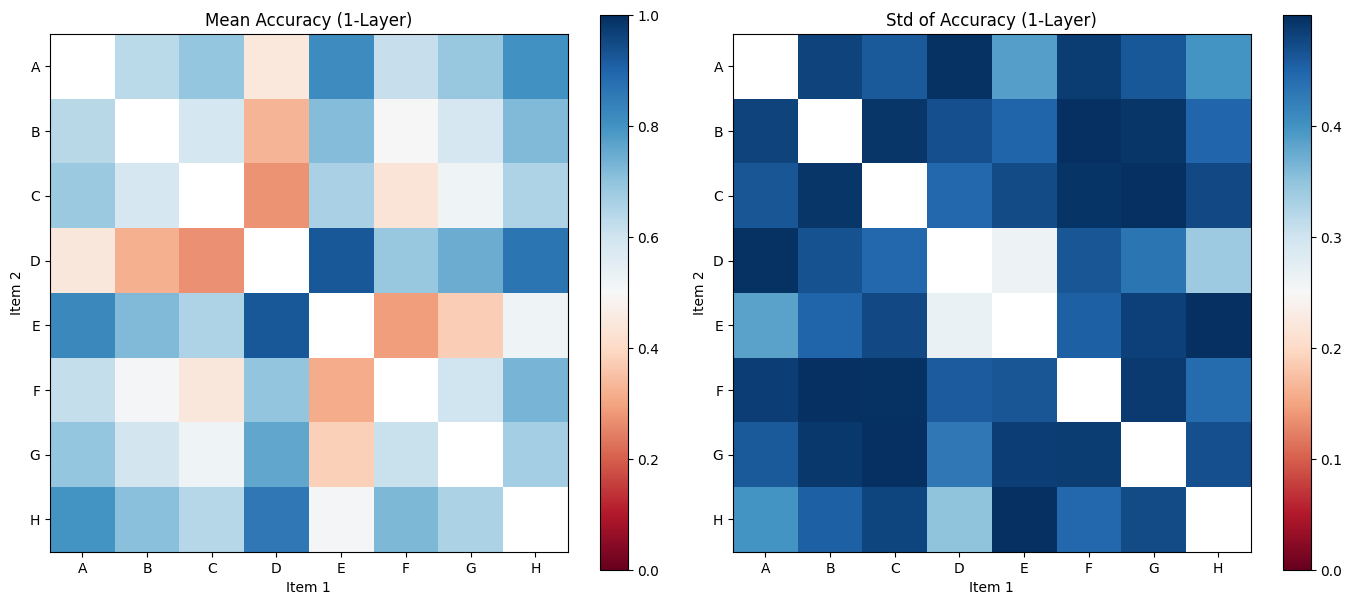

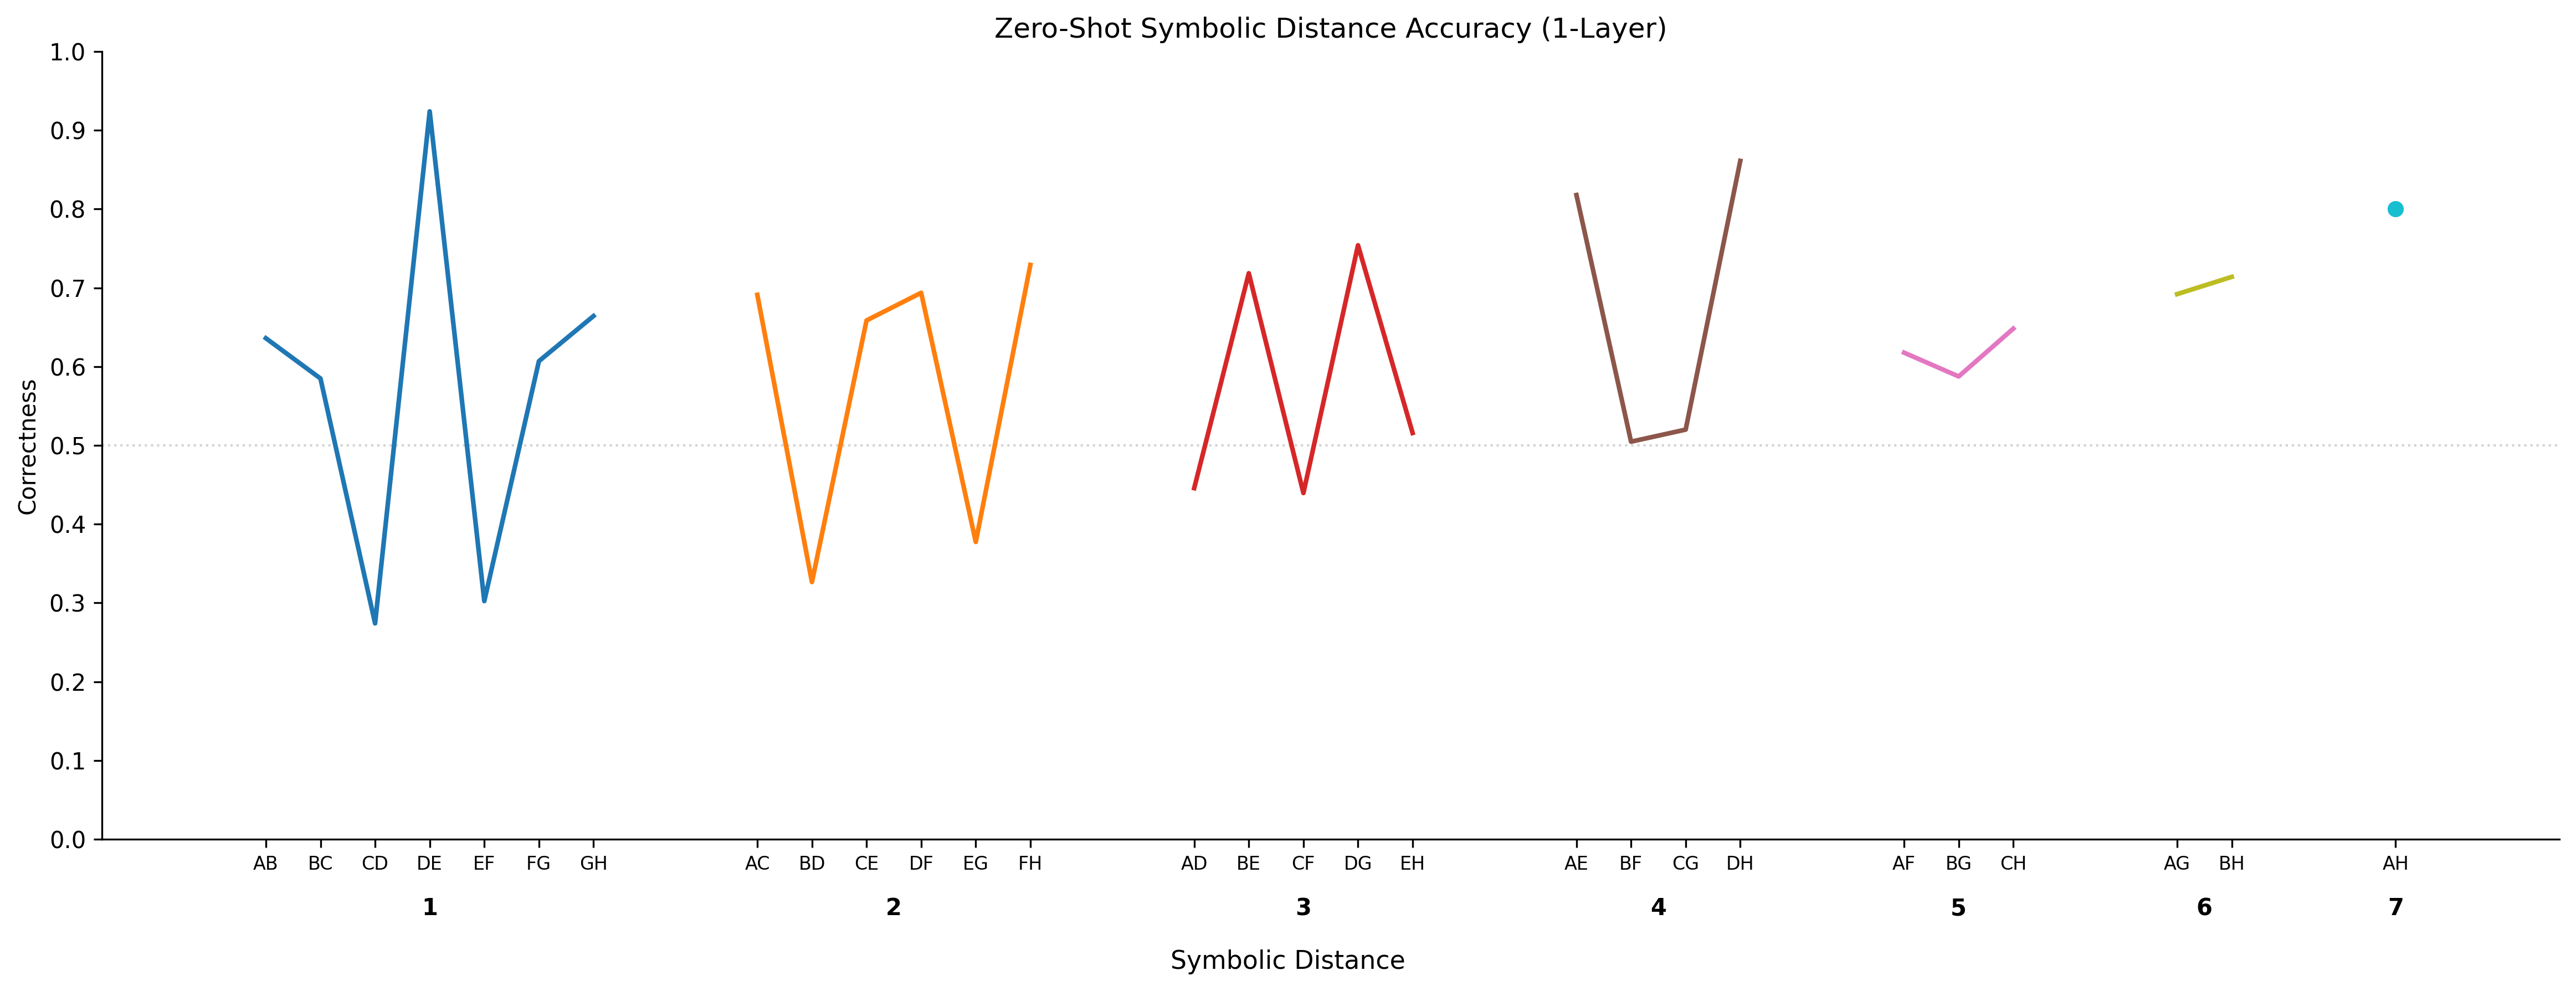

In [11]:
run_1layer(
    nm_pos=0.0,
    nm_neg=-7,
    alpha=0.01,
    list_linking=True,
    n_episodes=5000,
    item_dim=15,
    num_train_trials=200,
    list_linking_within_list_trials=10,
    linking_pair_trials=4,
    max_cos_sim=1.0
    )    

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def run_1layer_mod(nm_pos=0.0, nm_neg=-0.2, alpha=0.01, n_episodes=1000, item_dim=15,
               n_items=8, num_train_trials=20, list_linking=False, list_linking_within_list_trials=10, linking_pair_trials=4):
    """1-Layer Readout-Only Model.
    output = W_readout @ [e_i; e_j] + alpha * P @ [e_i; e_j]
    W_readout = [1,...,1, -1,...,-1], frozen. Items: random +-1 vectors, resampled each episode.
    """

    weighting = [np.log(2**i) for i in range(1, item_dim+1)]
    print(weighting)
    W_readout = np.concatenate([np.array(weighting), -np.array(weighting)])

    test_pairs = [(i, j) for i in range(n_items) for j in range(n_items) if i != j]
    n_test = len(test_pairs)

    pair_results = np.zeros((n_episodes, n_test))
    pos1_logits_all = np.zeros((n_episodes, n_items))
    pos2_logits_all = np.zeros((n_episodes, n_items))

    for ep in range(n_episodes):
        items = np.sign(np.random.randn(n_items, item_dim))
        P = np.zeros(2 * item_dim)

        train_trials = []
        if list_linking:
            for _ in range(list_linking_within_list_trials):
                pos1 = np.random.randint(0, 3)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))
            for _ in range(list_linking_within_list_trials):
                pos1 = np.random.randint(4, 7)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))
            for _ in range(linking_pair_trials):
                if np.random.rand() < 0.5:
                    train_trials.append((3, 4))
                else:
                    train_trials.append((4, 3))
        else:
            for _ in range(num_train_trials):
                pos1 = np.random.randint(n_items - 1)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))

        for (i, j) in train_trials:
            inp = np.concatenate([items[i], items[j]])
            output = (W_readout + alpha * P) @ inp

            choice = 1 if output > 0 else 0
            correct = 1 if i < j else 0
            reward = 1 if choice == correct else -1
            nm = nm_pos if reward == 1 else nm_neg

            P += nm * (output) * inp

        W_total = W_readout + alpha * P
        for t, (i, j) in enumerate(test_pairs):
            inp = np.concatenate([items[i], items[j]])
            output = W_total @ inp
            choice = 1 if output > 0 else 0
            correct = 1 if i < j else 0
            pair_results[ep, t] = 1 if choice == correct else 0

        for k in range(n_items):
            inp_pos1 = np.concatenate([items[k], np.zeros(item_dim)])
            pos1_logits_all[ep, k] = W_total @ inp_pos1
            inp_pos2 = np.concatenate([np.zeros(item_dim), items[k]])
            pos2_logits_all[ep, k] = W_total @ inp_pos2

    # Print
    item_labels = [chr(ord('A') + k) for k in range(n_items)]
    print(f"=== 1-Layer Readout-Only Model ===")
    print(f"nm_pos={nm_pos}, nm_neg={nm_neg}, alpha={alpha}, list_linking={list_linking}")
    print()
    print("Position 1 (item as item1) logits:")
    print(f"  Mean: {np.round(np.mean(pos1_logits_all, axis=0), 3)}")
    print(f"  Std:  {np.round(np.std(pos1_logits_all, axis=0), 3)}")
    print(f"  Items: {item_labels}")
    print()
    print("Position 2 (item as item2) logits:")
    print(f"  Mean: {np.round(np.mean(pos2_logits_all, axis=0), 3)}")
    print(f"  Std:  {np.round(np.std(pos2_logits_all, axis=0), 3)}")
    print(f"  Items: {item_labels}")
    print()

    mean_acc = np.mean(pair_results, axis=0)
    std_acc = np.std(pair_results, axis=0)

    # Heatmaps
    mean_grid = np.full((n_items, n_items), np.nan)
    std_grid = np.full((n_items, n_items), np.nan)
    for t, (i, j) in enumerate(test_pairs):
        mean_grid[j, i] = mean_acc[t]
        std_grid[j, i] = std_acc[t]

    labels = [chr(ord('A') + k) for k in range(n_items)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    im0 = axes[0].imshow(mean_grid, vmin=0, vmax=1, cmap='RdBu', origin='upper')
    axes[0].set_xticks(range(n_items)); axes[0].set_xticklabels(labels)
    axes[0].set_yticks(range(n_items)); axes[0].set_yticklabels(labels)
    axes[0].set_xlabel('Item 1'); axes[0].set_ylabel('Item 2')
    axes[0].set_title('Mean Accuracy (1-Layer)')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(std_grid, vmin=0, cmap='RdBu', origin='upper')
    axes[1].set_xticks(range(n_items)); axes[1].set_xticklabels(labels)
    axes[1].set_yticks(range(n_items)); axes[1].set_yticklabels(labels)
    axes[1].set_xlabel('Item 1'); axes[1].set_ylabel('Item 2')
    axes[1].set_title('Std of Accuracy (1-Layer)')
    fig.colorbar(im1, ax=axes[1])
    plt.tight_layout(); plt.show()

    # Symbolic distance plot
    zero_shot_trials = {}
    for t, (i, j) in enumerate(test_pairs):
        key = (min(i, j), max(i, j))
        if key not in zero_shot_trials:
            zero_shot_trials[key] = []
        zero_shot_trials[key].extend(pair_results[:, t].tolist())

    pair_avg = {k: np.mean(v) for k, v in zero_shot_trials.items()}
    correctness_by_sd = {sd: {} for sd in range(1, n_items)}
    for (i, j), avg in pair_avg.items():
        sd = abs(j - i)
        correctness_by_sd[sd][(i, j)] = avg

    fixed_sd_space = 1.5; fixed_pair_space = 0.5
    num_sd = n_items - 1
    total_pairs = sum(len(v) for v in correctness_by_sd.values())
    total_width = (num_sd + 1) * fixed_sd_space + total_pairs * fixed_pair_space
    fig_width = max(8, total_width * 0.6)
    pair_label_map = {(i, j): chr(i + ord('A')) + chr(j + ord('A'))
                      for i in range(n_items) for j in range(i + 1, n_items)}

    fig, ax = plt.subplots(figsize=(fig_width, 6), dpi=300)
    ax.axhline(y=0.5, color='lightgray', linestyle=':', linewidth=1, zorder=0)
    colors = plt.cm.tab10(np.linspace(0, 1, num_sd))
    all_x = []; all_labels = []; sd_centers = []; sd_labels = []
    current_x = fixed_sd_space

    for sd_idx, sd in enumerate(range(1, n_items)):
        pairs = correctness_by_sd[sd]
        sorted_pairs = sorted(pairs.keys(), key=lambda x: x[0])
        if not sorted_pairs:
            continue
        x_positions = []; means = []; p_labels = []
        for pi, pair in enumerate(sorted_pairs):
            x_pos = current_x + pi * fixed_pair_space
            x_positions.append(x_pos)
            means.append(pairs[pair])
            p_labels.append(pair_label_map.get(pair, f"{pair[0]}{pair[1]}"))
        x_positions = np.array(x_positions); means = np.array(means)
        color = colors[sd_idx]
        marker = 'o' if sd == n_items - 1 else ''
        ax.plot(x_positions, means, color=color, linewidth=2, marker=marker, markersize=6, label=f'SD {sd}')
        all_x.extend(x_positions.tolist()); all_labels.extend(p_labels)
        sd_centers.append((x_positions[0] + x_positions[-1]) / 2)
        sd_labels.append(str(sd))
        current_x = x_positions[-1] + fixed_sd_space

    ax.set_xticks(all_x); ax.set_xticklabels(all_labels, fontsize=8)
    ax2 = ax.secondary_xaxis('bottom')
    ax2.set_xticks(sd_centers); ax2.set_xticklabels(sd_labels, fontsize=10, fontweight='bold')
    ax2.tick_params(length=0, pad=25); ax2.spines['bottom'].set_visible(False)
    ax.set_title('Zero-Shot Symbolic Distance Accuracy (1-Layer)')
    ax.set_ylabel('Correctness'); ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    fig.text(0.5, 0.02, 'Symbolic Distance', ha='center', fontsize=11)
    ax.set_xlim(0, current_x)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.subplots_adjust(bottom=0.15); plt.show()


[np.float64(0.6931471805599453), np.float64(1.3862943611198906), np.float64(2.0794415416798357), np.float64(2.772588722239781), np.float64(3.4657359027997265), np.float64(4.1588830833596715), np.float64(4.852030263919617), np.float64(5.545177444479562), np.float64(6.238324625039508), np.float64(6.931471805599453), np.float64(7.6246189861593985), np.float64(8.317766166719343), np.float64(9.010913347279288), np.float64(9.704060527839234), np.float64(10.39720770839918)]
=== 1-Layer Readout-Only Model ===
nm_pos=0.0, nm_neg=-5.0, alpha=0.01, list_linking=False

Position 1 (item as item1) logits:
  Mean: [ 8.664  1.722 -0.091 -0.205 -0.078 -0.442 -1.318 -8.614]
  Std:  [19.321 18.34  17.994 18.123 17.96  17.982 17.604 19.16 ]
  Items: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Position 2 (item as item2) logits:
  Mean: [-8.504 -1.497 -0.147  0.012  0.165  0.363  1.811  8.95 ]
  Std:  [19.225 17.99  17.899 17.624 17.783 17.965 17.496 18.981]
  Items: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']



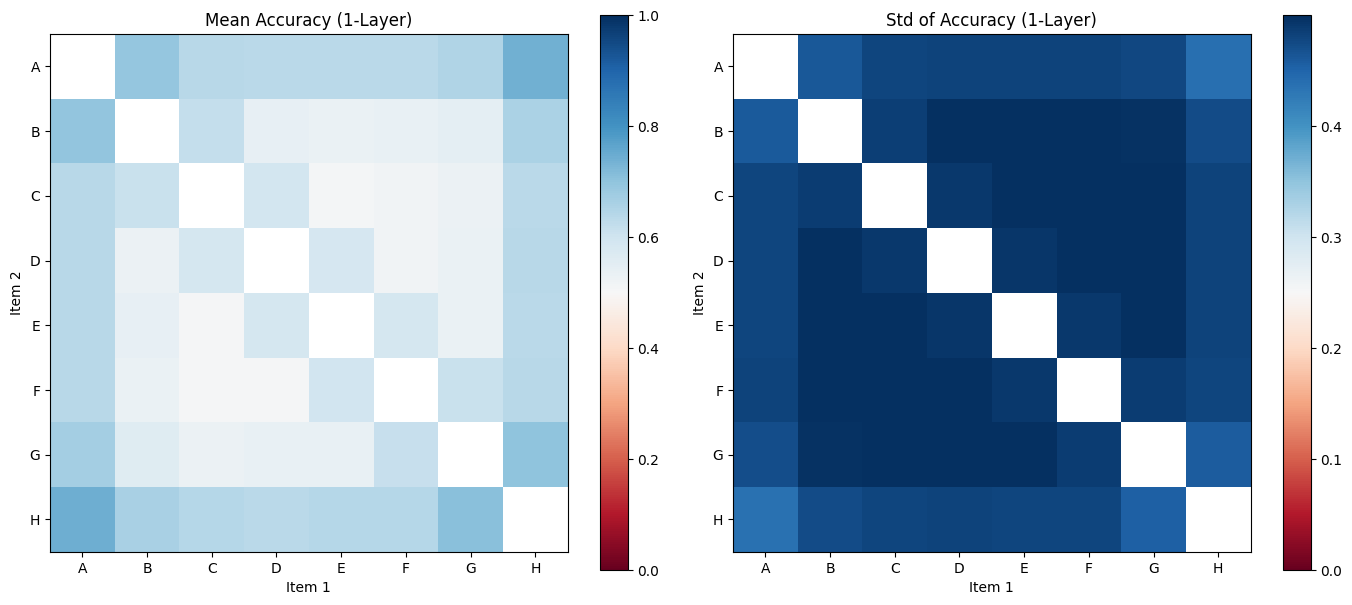

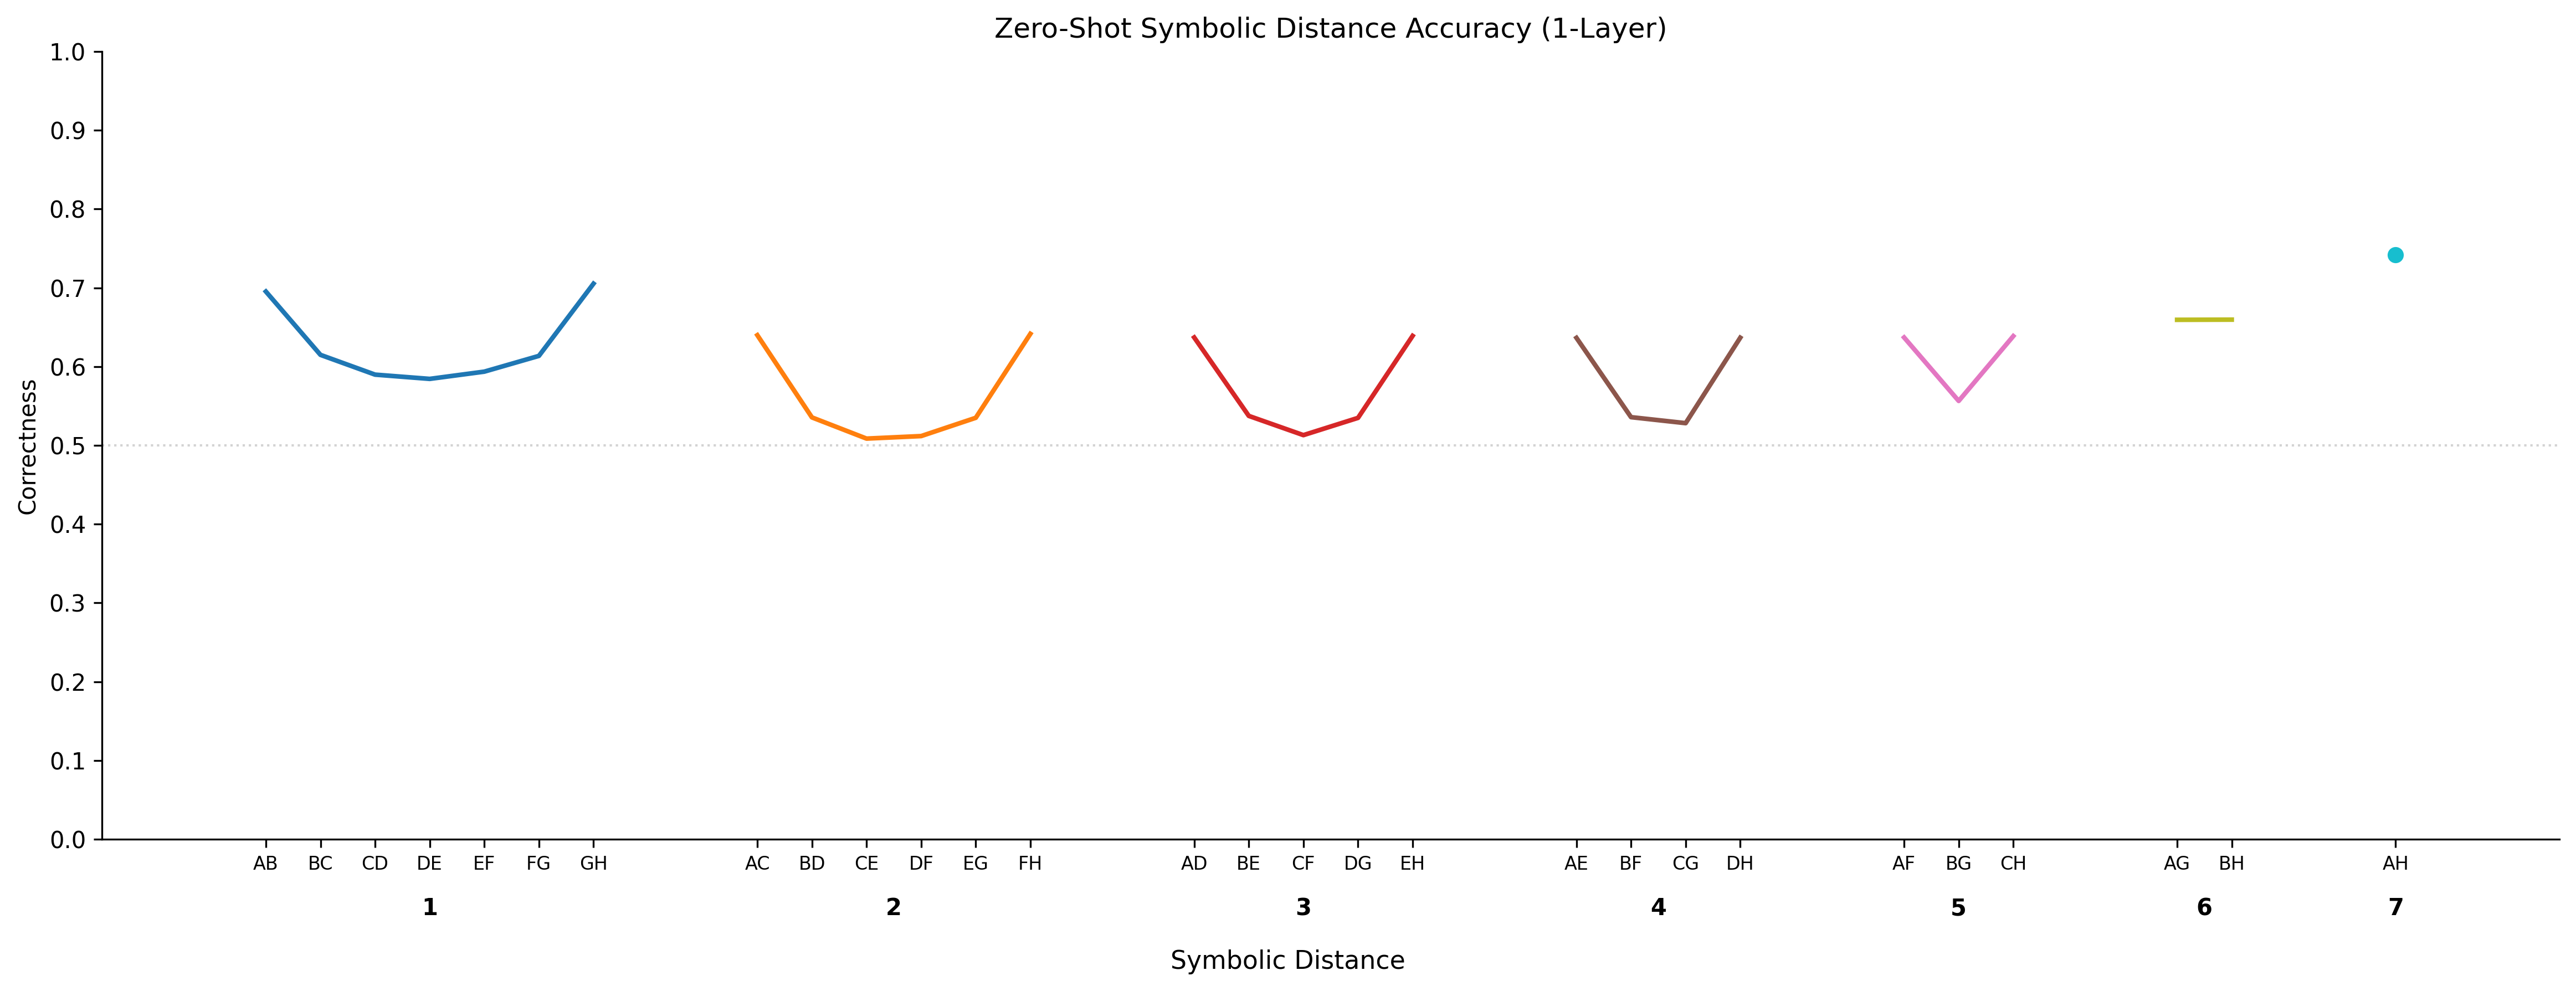

In [24]:
run_1layer_mod(
    nm_pos=0.0,
    nm_neg=-5.0,
    alpha=0.01,
    list_linking=False,
    n_episodes=5000,
    num_train_trials=20,
    list_linking_within_list_trials=100,
    linking_pair_trials=4
    )

In [20]:

import numpy as np

NBEPISODES = 100000
all_vals = np.zeros((NBEPISODES, 8))
ONLYUPDATEONERROR = True
REINSTATE = False

for numepisode in range(NBEPISODES):
    vals = 2.0 * np.random.rand(8) - 1.0
    for i in range(20):
        neg_decay = 1.0 - 0.5 * (i / 20)
        pos_decay = 1.0 - 0.2 * (i / 20)
        pos1 = np.random.randint(7)
        pos2 = pos1 + 1
        res = vals[pos2] - vals[pos1]
        correct = res < 0
        incr = (1 if res > 0 else -1) * (-1 if correct else 1)
        if correct and ONLYUPDATEONERROR:
            incr *= 0.5 * pos_decay
        else:
            incr *= neg_decay
        vals[pos1] += incr
        vals[pos2] -= incr
        if REINSTATE:
            if pos1 > 0:
                vals[pos1-1] += .5 * incr
            if pos2 < 7:
                vals[pos2+1] -= .5 * incr
    all_vals[numepisode] = vals

print("Average value vector:", np.round(np.mean(all_vals, axis=0), 2))
print("Standard deviation:", np.round(np.std(all_vals, axis=0), 4))


Average value vector: [ 1.6   0.12  0.01  0.   -0.   -0.01 -0.11 -1.6 ]
Standard deviation: [0.9028 1.1984 1.2383 1.244  1.2435 1.2407 1.1975 0.9008]


fc2 weight shape: torch.Size([1, 30])
fc2 bias: None (no bias)


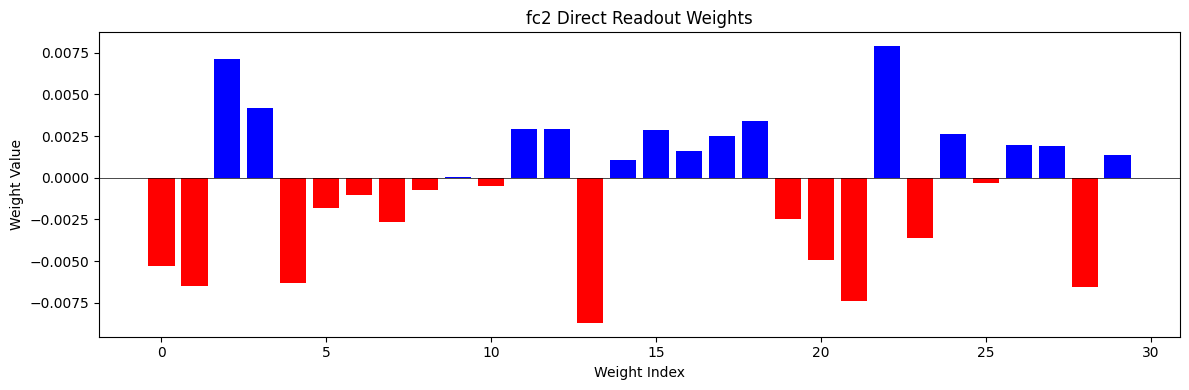

In [28]:
import torch
import matplotlib.pyplot as plt

ckpt_path = "/gpfs/radev/pi/dijk/dfl32/3factor/checkpoints/mlp_hs200_lr0.0001_extralayers0_bce_greedy_scalaralpha0_frzNM_frzHT_frzAlpha1_directreadout_linearhebb_noEmbed_linearact_nobias1_directNM_p0.0_n-1.0_20260306_012038/checkpoint_ep359999.pt"
ckpt = torch.load(ckpt_path, map_location="cpu")

state = ckpt["model_state_dict"]
weights = state['fc2.weight'].squeeze().numpy()

print(f"fc2 weight shape: {state['fc2.weight'].shape}")
if "fc2.bias" in state:
    print(f"fc2 bias: {state['fc2.bias']}")
else:
    print("fc2 bias: None (no bias)")

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['blue' if w >= 0 else 'red' for w in weights]
ax.bar(range(len(weights)), weights, color=colors)
ax.set_xlabel('Weight Index')
ax.set_ylabel('Weight Value')
ax.set_title('fc2 Direct Readout Weights')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


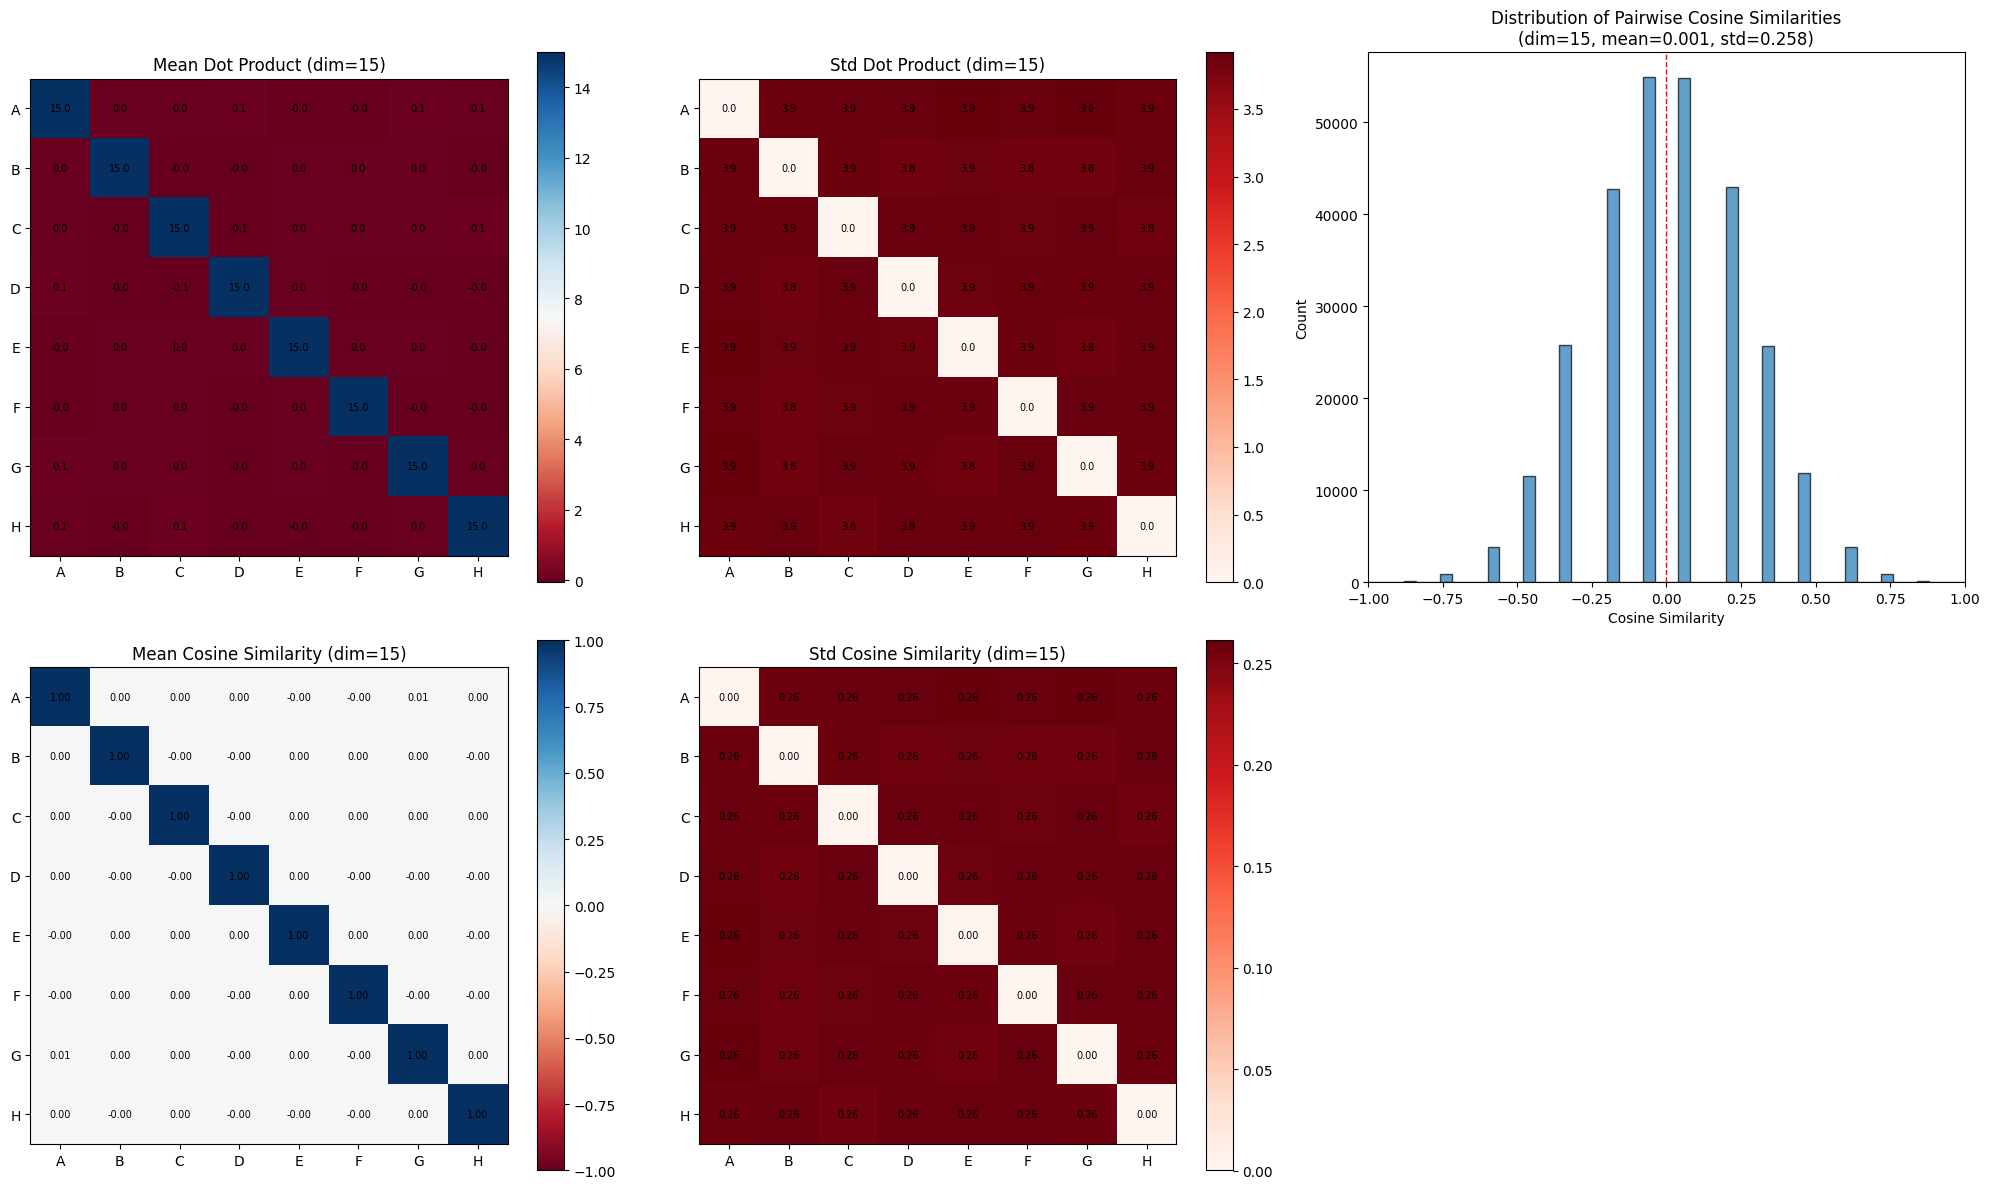

In [103]:
import numpy as np
import matplotlib.pyplot as plt

n_items = 8
item_dim = 15
n_samples = 10000

dot_products = np.zeros((n_samples, n_items, n_items))
cos_angles = np.zeros((n_samples, n_items, n_items))
for s in range(n_samples):
    items = np.sign(np.random.randn(n_items, item_dim))
    dot_products[s] = items @ items.T
    norms = np.linalg.norm(items, axis=1, keepdims=True)
    cos_angles[s] = (items @ items.T) / (norms @ norms.T)

avg_dots = np.mean(dot_products, axis=0)
std_dots = np.std(dot_products, axis=0)
avg_cos = np.mean(cos_angles, axis=0)
std_cos = np.std(cos_angles, axis=0)

# Extract off-diagonal cosine similarities for histogram
off_diag_cos = []
for s in range(n_samples):
    for i in range(n_items):
        for j in range(i + 1, n_items):
            off_diag_cos.append(cos_angles[s, i, j])
off_diag_cos = np.array(off_diag_cos)

labels = [chr(ord('A') + k) for k in range(n_items)]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

im0 = axes[0,0].imshow(avg_dots, cmap='RdBu', origin='upper')
axes[0,0].set_xticks(range(n_items)); axes[0,0].set_xticklabels(labels)
axes[0,0].set_yticks(range(n_items)); axes[0,0].set_yticklabels(labels)
axes[0,0].set_title(f'Mean Dot Product (dim={item_dim})')
fig.colorbar(im0, ax=axes[0,0])
for i in range(n_items):
    for j in range(n_items):
        axes[0,0].text(j, i, f'{avg_dots[i,j]:.1f}', ha='center', va='center', fontsize=7)

im1 = axes[0,1].imshow(std_dots, cmap='Reds', origin='upper')
axes[0,1].set_xticks(range(n_items)); axes[0,1].set_xticklabels(labels)
axes[0,1].set_yticks(range(n_items)); axes[0,1].set_yticklabels(labels)
axes[0,1].set_title(f'Std Dot Product (dim={item_dim})')
fig.colorbar(im1, ax=axes[0,1])
for i in range(n_items):
    for j in range(n_items):
        axes[0,1].text(j, i, f'{std_dots[i,j]:.1f}', ha='center', va='center', fontsize=7)

im2 = axes[1,0].imshow(avg_cos, cmap='RdBu', vmin=-1, vmax=1, origin='upper')
axes[1,0].set_xticks(range(n_items)); axes[1,0].set_xticklabels(labels)
axes[1,0].set_yticks(range(n_items)); axes[1,0].set_yticklabels(labels)
axes[1,0].set_title(f'Mean Cosine Similarity (dim={item_dim})')
fig.colorbar(im2, ax=axes[1,0])
for i in range(n_items):
    for j in range(n_items):
        axes[1,0].text(j, i, f'{avg_cos[i,j]:.2f}', ha='center', va='center', fontsize=7)

im3 = axes[1,1].imshow(std_cos, cmap='Reds', origin='upper')
axes[1,1].set_xticks(range(n_items)); axes[1,1].set_xticklabels(labels)
axes[1,1].set_yticks(range(n_items)); axes[1,1].set_yticklabels(labels)
axes[1,1].set_title(f'Std Cosine Similarity (dim={item_dim})')
fig.colorbar(im3, ax=axes[1,1])
for i in range(n_items):
    for j in range(n_items):
        axes[1,1].text(j, i, f'{std_cos[i,j]:.2f}', ha='center', va='center', fontsize=7)

axes[0,2].hist(off_diag_cos, bins=50, edgecolor='black', alpha=0.7)
axes[0,2].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0,2].set_xlabel('Cosine Similarity')
axes[0,2].set_ylabel('Count')
axes[0,2].set_title(f'Distribution of Pairwise Cosine Similarities\n(dim={item_dim}, mean={off_diag_cos.mean():.3f}, std={off_diag_cos.std():.3f})')
axes[0,2].set_xlim(-1, 1)

axes[1,2].axis('off')

plt.tight_layout()
plt.show()


In [33]:
print(state)
print(state['fc2.weight'].squeeze().numpy())
print(state['direct_nm_neg'].item())
print(state['direct_nm_pos'].item())

OrderedDict([('alpha', tensor(0.0100)), ('neuromodulator_multiplier', tensor([1.])), ('hebbian_trace_multiplier', tensor([1.])), ('direct_nm_pos', tensor(4.7726)), ('direct_nm_neg', tensor(-7.9158)), ('fc2.weight', tensor([[-5.3002e-03, -6.5008e-03,  7.1381e-03,  4.2008e-03, -6.3230e-03,
         -1.8044e-03, -1.0188e-03, -2.6294e-03, -7.4232e-04,  4.3039e-05,
         -5.0061e-04,  2.9130e-03,  2.9213e-03, -8.7043e-03,  1.0651e-03,
          2.8790e-03,  1.5786e-03,  2.5221e-03,  3.4024e-03, -2.4698e-03,
         -4.9224e-03, -7.4126e-03,  7.8932e-03, -3.5891e-03,  2.6232e-03,
         -3.2352e-04,  1.9715e-03,  1.8823e-03, -6.5482e-03,  1.3623e-03]])), ('hidden_to_reward.weight', tensor([[0.4663]])), ('hidden_to_reward.bias', tensor([-0.4087])), ('reward_linear.weight', tensor([[0.4629]])), ('reward_linear.bias', tensor([0.5120])), ('neuromodulator_out.weight', tensor([[ 0.4022],
        [-0.6490]])), ('neuromodulator_out.bias', tensor([-0.9619, -0.1861])), ('value_out.weight', tenso

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def run_1layer_mod(
    nm_pos=0.0,
    nm_neg=-0.2,
    alpha=0.01,
    weights=None,
    n_episodes=1000,
    item_dim=15,
    n_items=8,
    num_train_trials=20,
    list_linking=False,
    list_linking_within_list_trials=10,
    linking_pair_trials=4
    ):
    """1-Layer Readout-Only Model.
    output = W_readout @ [e_i; e_j] + alpha * P @ [e_i; e_j]
    W_readout = [1,...,1, -1,...,-1], frozen. Items: random +-1 vectors, resampled each episode.
    """

    if weights is None:
        weighting = [np.log(2**i) for i in range(1, item_dim+1)]
        W_readout = np.concatenate([np.array(weighting), -np.array(weighting)])
    else:
        W_readout = weights
    print(W_readout)

    test_pairs = [(i, j) for i in range(n_items) for j in range(n_items) if i != j]
    n_test = len(test_pairs)

    pair_results = np.zeros((n_episodes, n_test))
    pos1_logits_all = np.zeros((n_episodes, n_items))
    pos2_logits_all = np.zeros((n_episodes, n_items))

    for ep in range(n_episodes):
        items = np.sign(np.random.randn(n_items, item_dim))
        P = np.zeros(2 * item_dim)

        train_trials = []
        if list_linking:
            for _ in range(list_linking_within_list_trials):
                pos1 = np.random.randint(0, 3)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))
            for _ in range(list_linking_within_list_trials):
                pos1 = np.random.randint(4, 7)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))
            for _ in range(linking_pair_trials):
                if np.random.rand() < 0.5:
                    train_trials.append((3, 4))
                else:
                    train_trials.append((4, 3))
        else:
            for _ in range(num_train_trials):
                pos1 = np.random.randint(n_items - 1)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))

        for (i, j) in train_trials:
            inp = np.concatenate([items[i], items[j]])
            output = (W_readout + alpha * P) @ inp

            choice = 1 if output > 0 else 0
            correct = 1 if i < j else 0
            reward = 1 if choice == correct else -1
            nm = nm_pos if reward == 1 else nm_neg

            P += nm * (output) * inp

        W_total = W_readout + alpha * P
        for t, (i, j) in enumerate(test_pairs):
            inp = np.concatenate([items[i], items[j]])
            output = W_total @ inp
            choice = 1 if output > 0 else 0
            correct = 1 if i < j else 0
            pair_results[ep, t] = 1 if choice == correct else 0

        for k in range(n_items):
            inp_pos1 = np.concatenate([items[k], np.zeros(item_dim)])
            pos1_logits_all[ep, k] = W_total @ inp_pos1
            inp_pos2 = np.concatenate([np.zeros(item_dim), items[k]])
            pos2_logits_all[ep, k] = W_total @ inp_pos2

    # Print
    item_labels = [chr(ord('A') + k) for k in range(n_items)]
    print(f"=== 1-Layer Readout-Only Model ===")
    print(f"nm_pos={nm_pos}, nm_neg={nm_neg}, alpha={alpha}, list_linking={list_linking}")
    print()
    print("Position 1 (item as item1) logits:")
    print(f"  Mean: {np.round(np.mean(pos1_logits_all, axis=0), 3)}")
    print(f"  Std:  {np.round(np.std(pos1_logits_all, axis=0), 3)}")
    print(f"  Items: {item_labels}")
    print()
    print("Position 2 (item as item2) logits:")
    print(f"  Mean: {np.round(np.mean(pos2_logits_all, axis=0), 3)}")
    print(f"  Std:  {np.round(np.std(pos2_logits_all, axis=0), 3)}")
    print(f"  Items: {item_labels}")
    print()

    mean_acc = np.mean(pair_results, axis=0)
    std_acc = np.std(pair_results, axis=0)

    # Heatmaps
    mean_grid = np.full((n_items, n_items), np.nan)
    std_grid = np.full((n_items, n_items), np.nan)
    for t, (i, j) in enumerate(test_pairs):
        mean_grid[j, i] = mean_acc[t]
        std_grid[j, i] = std_acc[t]

    labels = [chr(ord('A') + k) for k in range(n_items)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    im0 = axes[0].imshow(mean_grid, vmin=0, vmax=1, cmap='RdBu', origin='upper')
    axes[0].set_xticks(range(n_items)); axes[0].set_xticklabels(labels)
    axes[0].set_yticks(range(n_items)); axes[0].set_yticklabels(labels)
    axes[0].set_xlabel('Item 1'); axes[0].set_ylabel('Item 2')
    axes[0].set_title('Mean Accuracy (1-Layer)')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(std_grid, vmin=0, cmap='RdBu', origin='upper')
    axes[1].set_xticks(range(n_items)); axes[1].set_xticklabels(labels)
    axes[1].set_yticks(range(n_items)); axes[1].set_yticklabels(labels)
    axes[1].set_xlabel('Item 1'); axes[1].set_ylabel('Item 2')
    axes[1].set_title('Std of Accuracy (1-Layer)')
    fig.colorbar(im1, ax=axes[1])
    plt.tight_layout(); plt.show()

    # Symbolic distance plot
    zero_shot_trials = {}
    for t, (i, j) in enumerate(test_pairs):
        key = (min(i, j), max(i, j))
        if key not in zero_shot_trials:
            zero_shot_trials[key] = []
        zero_shot_trials[key].extend(pair_results[:, t].tolist())

    pair_avg = {k: np.mean(v) for k, v in zero_shot_trials.items()}
    correctness_by_sd = {sd: {} for sd in range(1, n_items)}
    for (i, j), avg in pair_avg.items():
        sd = abs(j - i)
        correctness_by_sd[sd][(i, j)] = avg

    fixed_sd_space = 1.5; fixed_pair_space = 0.5
    num_sd = n_items - 1
    total_pairs = sum(len(v) for v in correctness_by_sd.values())
    total_width = (num_sd + 1) * fixed_sd_space + total_pairs * fixed_pair_space
    fig_width = max(8, total_width * 0.6)
    pair_label_map = {(i, j): chr(i + ord('A')) + chr(j + ord('A'))
                      for i in range(n_items) for j in range(i + 1, n_items)}

    fig, ax = plt.subplots(figsize=(fig_width, 6), dpi=300)
    ax.axhline(y=0.5, color='lightgray', linestyle=':', linewidth=1, zorder=0)
    colors = plt.cm.tab10(np.linspace(0, 1, num_sd))
    all_x = []; all_labels = []; sd_centers = []; sd_labels = []
    current_x = fixed_sd_space

    for sd_idx, sd in enumerate(range(1, n_items)):
        pairs = correctness_by_sd[sd]
        sorted_pairs = sorted(pairs.keys(), key=lambda x: x[0])
        if not sorted_pairs:
            continue
        x_positions = []; means = []; p_labels = []
        for pi, pair in enumerate(sorted_pairs):
            x_pos = current_x + pi * fixed_pair_space
            x_positions.append(x_pos)
            means.append(pairs[pair])
            p_labels.append(pair_label_map.get(pair, f"{pair[0]}{pair[1]}"))
        x_positions = np.array(x_positions); means = np.array(means)
        color = colors[sd_idx]
        marker = 'o' if sd == n_items - 1 else ''
        ax.plot(x_positions, means, color=color, linewidth=2, marker=marker, markersize=6, label=f'SD {sd}')
        all_x.extend(x_positions.tolist()); all_labels.extend(p_labels)
        sd_centers.append((x_positions[0] + x_positions[-1]) / 2)
        sd_labels.append(str(sd))
        current_x = x_positions[-1] + fixed_sd_space

    ax.set_xticks(all_x); ax.set_xticklabels(all_labels, fontsize=8)
    ax2 = ax.secondary_xaxis('bottom')
    ax2.set_xticks(sd_centers); ax2.set_xticklabels(sd_labels, fontsize=10, fontweight='bold')
    ax2.tick_params(length=0, pad=25); ax2.spines['bottom'].set_visible(False)
    ax.set_title('Zero-Shot Symbolic Distance Accuracy (1-Layer)')
    ax.set_ylabel('Correctness'); ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    fig.text(0.5, 0.02, 'Symbolic Distance', ha='center', fontsize=11)
    ax.set_xlim(0, current_x)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.subplots_adjust(bottom=0.15); plt.show()


fc2 weight shape: torch.Size([1, 30])
fc2 bias: None (no bias)


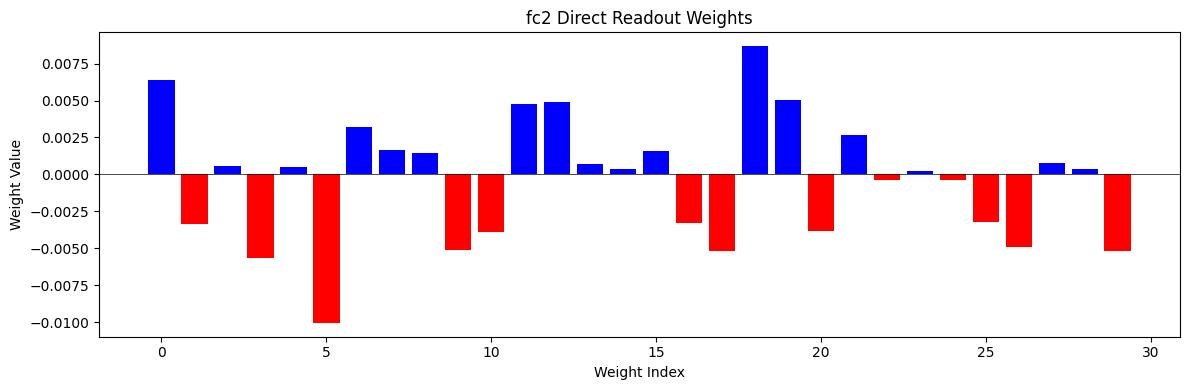

OrderedDict([('alpha', tensor(0.0100)),
             ('neuromodulator_multiplier', tensor([1.])),
             ('hebbian_trace_multiplier', tensor([1.])),
             ('direct_nm_pos', tensor(4.3795)),
             ('direct_nm_neg', tensor(-8.8409)),
             ('fc2.weight',
              tensor([[ 0.0064, -0.0033,  0.0006, -0.0057,  0.0005, -0.0101,  0.0032,  0.0017,
                        0.0015, -0.0051, -0.0039,  0.0048,  0.0049,  0.0007,  0.0004,  0.0016,
                       -0.0033, -0.0052,  0.0087,  0.0050, -0.0038,  0.0027, -0.0004,  0.0002,
                       -0.0004, -0.0032, -0.0049,  0.0008,  0.0004, -0.0052]])),
             ('hidden_to_reward.weight', tensor([[0.4663]])),
             ('hidden_to_reward.bias', tensor([-0.4087])),
             ('reward_linear.weight', tensor([[0.4629]])),
             ('reward_linear.bias', tensor([0.5120])),
             ('neuromodulator_out.weight',
              tensor([[ 0.4022],
                      [-0.6490]])),
       

In [126]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

base_dir = Path("/gpfs/radev/pi/dijk/dfl32/3factor/checkpoints/")
run = Path("mlp_hs200_lr0.0001_extralayers0_bce_greedy_scalaralpha0_frzNM_frzHT_frzAlpha1_directreadout_linearhebb_noEmbed_linearact_nobias1_directNM_p0.0_n-1.0_20260306_012038")
checkpoint_num = 399999
checkpoint = Path(f"checkpoint_ep{checkpoint_num}.pt")


ckpt_path = base_dir / run / checkpoint
ckpt = torch.load(ckpt_path, map_location="cpu")

state = ckpt["model_state_dict"]

weights = state['fc2.weight'].squeeze().numpy()

print(f"fc2 weight shape: {state['fc2.weight'].shape}")
if "fc2.bias" in state:
    print(f"fc2 bias: {state['fc2.bias']}")
else:
    print("fc2 bias: None (no bias)")

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['blue' if w >= 0 else 'red' for w in weights]
ax.bar(range(len(weights)), weights, color=colors)
ax.set_xlabel('Weight Index')
ax.set_ylabel('Weight Value')
ax.set_title('fc2 Direct Readout Weights')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()
state

[ 0.00639764 -0.0033497   0.0005928  -0.00568396  0.0005158  -0.01005759
  0.00322131  0.00166467  0.00147757 -0.00512179 -0.00392876  0.0047635
  0.00489552  0.0007363   0.00036161  0.00157424 -0.00331176 -0.0052093
  0.00868354  0.00501376 -0.00382424  0.00269331 -0.00038952  0.00022591
 -0.00035347 -0.0032155  -0.00490362  0.00079719  0.00037173 -0.00519159]
=== 1-Layer Readout-Only Model ===
nm_pos=4.379528999328613, nm_neg=-8.840919494628906, alpha=0.01, list_linking=False

Position 1 (item as item1) logits:
  Mean: [ 0.099  0.004  0.007  0.004 -0.003 -0.005 -0.017 -0.104]
  Std:  [0.356 0.421 0.347 0.398 0.4   0.473 0.366 0.335]
  Items: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Position 2 (item as item2) logits:
  Mean: [-0.103 -0.014 -0.005 -0.     0.     0.006  0.012  0.098]
  Std:  [0.362 0.376 0.363 0.362 0.428 0.423 0.422 0.337]
  Items: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']



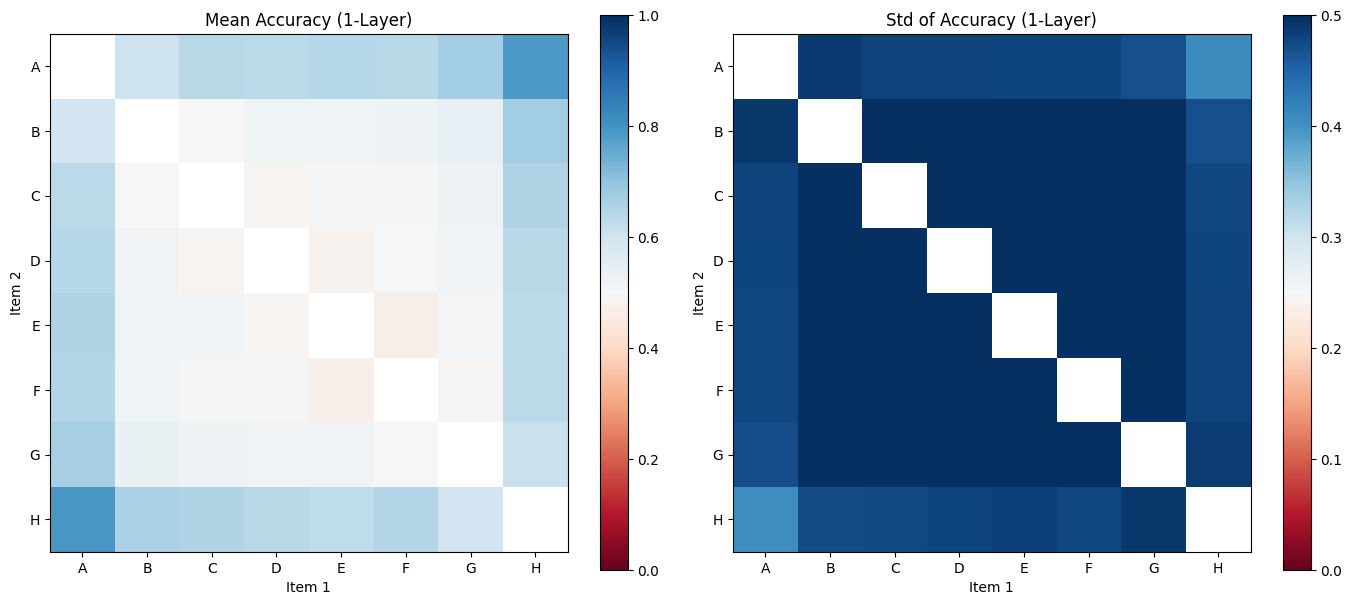

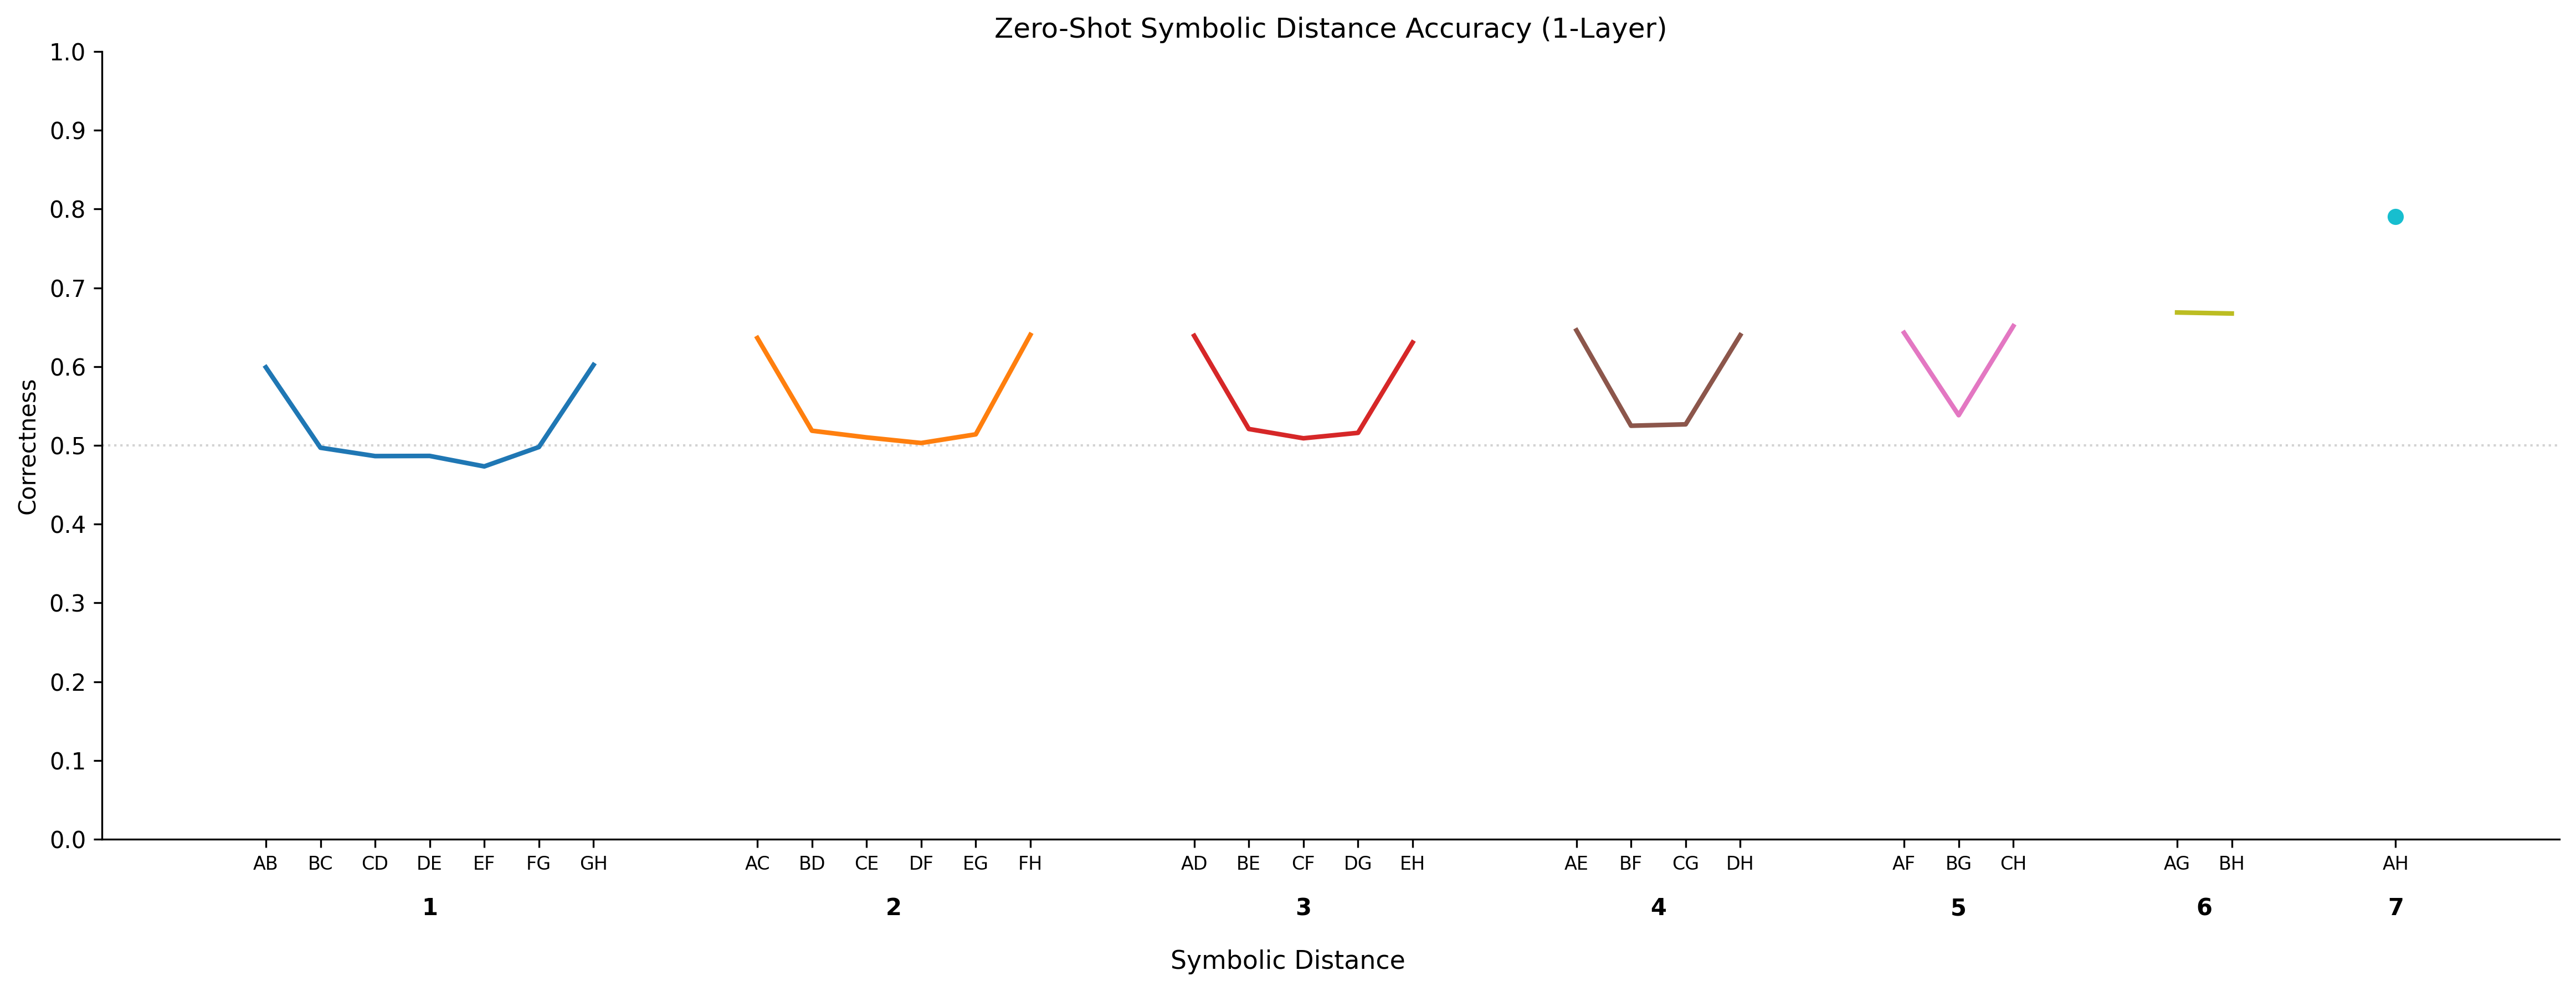

In [128]:

weights = state['fc2.weight'].squeeze().numpy()
nm_neg = state['direct_nm_neg'].item()
nm_pos = state['direct_nm_pos'].item()

run_1layer_mod(
    nm_pos=nm_pos,
    nm_neg=nm_neg,
    alpha=0.01,
    weights=weights,
    list_linking=False,
    n_episodes=5000,
    num_train_trials=20,
    list_linking_within_list_trials=100,
    linking_pair_trials=4
    )

In [163]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def run_1layer_basis(nm_pos=0.0, nm_neg=-0.2, alpha=0.01, n_episodes=1000,
                     n_items=8, num_train_trials=20, list_linking=False,
                     list_linking_within_list_trials=10, linking_pair_trials=4,
                     use_transform=False, hebb_bias=False, anti_diag_scale=1.0,
                     input_noise_std=0.0, plastic_in_transform=False):
    """1-Layer Readout-Only Model with standard basis item vectors.
    Items are fixed e_0,...,e_{n-1} in R^n (identity matrix rows).
    Only trial order is random across episodes.
    If use_transform=True, applies [[I,-I],[-I,I]] to input before readout (like 2-layer innate W1).
    If input_noise_std>0, each item is scaled by (1 + N(0, std)) per episode (consistent within episode).
    If plastic_in_transform=True (requires use_transform), plastic weights are a matrix in the
    transform layer instead of a vector in the readout. Readout stays all ones.
    """
    item_dim = n_items
    items = np.eye(n_items)

    if use_transform:
        I_mat = np.eye(item_dim)
        W_transform = np.block([[I_mat, -anti_diag_scale*I_mat], [-anti_diag_scale*I_mat, I_mat]])
        hidden_dim = 2 * item_dim
    else:
        W_transform = None
        hidden_dim = 2 * item_dim
        if plastic_in_transform:
            raise ValueError("plastic_in_transform requires use_transform=True")

    W_readout = np.ones(hidden_dim)
    input_dim = 2 * item_dim

    test_pairs = [(i, j) for i in range(n_items) for j in range(n_items) if i != j]
    n_test = len(test_pairs)

    pair_results = np.zeros((n_episodes, n_test))
    pos1_logits_all = np.zeros((n_episodes, n_items))
    pos2_logits_all = np.zeros((n_episodes, n_items))

    for ep in tqdm(range(n_episodes)):
        if plastic_in_transform:
            P_mat = np.zeros((hidden_dim, input_dim))
        else:
            P = np.zeros(hidden_dim)

        if input_noise_std > 0:
            noise_scale = 1.0 + np.random.randn(n_items) * input_noise_std
            scaled_items = items * noise_scale[:, None]
        else:
            scaled_items = items

        train_trials = []
        if list_linking:
            for _ in range(list_linking_within_list_trials):
                pos1 = np.random.randint(0, 3)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))
            for _ in range(list_linking_within_list_trials):
                pos1 = np.random.randint(4, 7)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))
            for _ in range(linking_pair_trials):
                if np.random.rand() < 0.5:
                    train_trials.append((3, 4))
                else:
                    train_trials.append((4, 3))
        else:
            for _ in range(num_train_trials):
                pos1 = np.random.randint(n_items - 1)
                pos2 = pos1 + 1
                if np.random.rand() < 0.5:
                    train_trials.append((pos1, pos2))
                else:
                    train_trials.append((pos2, pos1))

        for (i, j) in train_trials:
            raw_inp = np.concatenate([scaled_items[i], scaled_items[j]])
            if plastic_in_transform:
                hidden = (W_transform + alpha * P_mat) @ raw_inp
                hidden+=1
                output = W_readout @ hidden
            else:
                hidden = W_transform @ raw_inp if use_transform else raw_inp
                output = (W_readout + alpha * P) @ hidden

            choice = 1 if output > 0 else 0
            correct = 1 if i < j else 0
            reward = 1 if choice == correct else -1
            nm = nm_pos if reward == 1 else nm_neg

            if plastic_in_transform:
                trace = (output + 1) if hebb_bias else output
                P_mat += nm * trace * np.outer(hidden, raw_inp)
            else:
                if hebb_bias:
                    P += nm * (output+1) * hidden
                else:
                    P += nm * output * hidden

        for t, (i, j) in enumerate(test_pairs):
            raw_inp = np.concatenate([scaled_items[i], scaled_items[j]])
            if plastic_in_transform:
                hidden = (W_transform + alpha * P_mat) @ raw_inp
                hidden+=1
                output = W_readout @ hidden
            else:
                hidden = W_transform @ raw_inp if use_transform else raw_inp
                output = (W_readout + alpha * P) @ hidden
            choice = 1 if output > 0 else 0
            correct = 1 if i < j else 0
            pair_results[ep, t] = 1 if choice == correct else 0

        for k in range(n_items):
            raw_pos1 = np.concatenate([scaled_items[k], np.zeros(item_dim)])
            if plastic_in_transform:
                hidden_pos1 = (W_transform + alpha * P_mat) @ raw_pos1
                pos1_logits_all[ep, k] = W_readout @ hidden_pos1
            else:
                hidden_pos1 = W_transform @ raw_pos1 if use_transform else raw_pos1
                pos1_logits_all[ep, k] = (W_readout + alpha * P) @ hidden_pos1

            raw_pos2 = np.concatenate([np.zeros(item_dim), scaled_items[k]])
            if plastic_in_transform:
                hidden_pos2 = (W_transform + alpha * P_mat) @ raw_pos2
                pos2_logits_all[ep, k] = W_readout @ hidden_pos2
            else:
                hidden_pos2 = W_transform @ raw_pos2 if use_transform else raw_pos2
                pos2_logits_all[ep, k] = (W_readout + alpha * P) @ hidden_pos2

    # Print
    item_labels = [chr(ord('A') + k) for k in range(n_items)]
    print(f"=== 1-Layer Basis Model (item_dim={item_dim}, transform={use_transform}, plastic_in_transform={plastic_in_transform}) ===")
    print(f"nm_pos={nm_pos}, nm_neg={nm_neg}, alpha={alpha}, list_linking={list_linking}")
    print()
    print("Position 1 (item as item1) logits:")
    print(f"  Mean: {np.round(np.mean(pos1_logits_all, axis=0), 3)}")
    print(f"  Std:  {np.round(np.std(pos1_logits_all, axis=0), 3)}")
    print(f"  Items: {item_labels}")
    print()
    print("Position 2 (item as item2) logits:")
    print(f"  Mean: {np.round(np.mean(pos2_logits_all, axis=0), 3)}")
    print(f"  Std:  {np.round(np.std(pos2_logits_all, axis=0), 3)}")
    print(f"  Items: {item_labels}")
    print()

    mean_acc = np.mean(pair_results, axis=0)
    std_acc = np.std(pair_results, axis=0)

    mean_grid = np.full((n_items, n_items), np.nan)
    std_grid = np.full((n_items, n_items), np.nan)
    for t, (i, j) in enumerate(test_pairs):
        mean_grid[j, i] = mean_acc[t]
        std_grid[j, i] = std_acc[t]

    labels = [chr(ord('A') + k) for k in range(n_items)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    im0 = axes[0].imshow(mean_grid, vmin=0, vmax=1, cmap='RdBu', origin='upper')
    axes[0].set_xticks(range(n_items)); axes[0].set_xticklabels(labels)
    axes[0].set_yticks(range(n_items)); axes[0].set_yticklabels(labels)
    axes[0].set_xlabel('Item 1'); axes[0].set_ylabel('Item 2')
    axes[0].set_title('Mean Accuracy (1-Layer Basis)')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(std_grid, vmin=0, cmap='RdBu', origin='upper')
    axes[1].set_xticks(range(n_items)); axes[1].set_xticklabels(labels)
    axes[1].set_yticks(range(n_items)); axes[1].set_yticklabels(labels)
    axes[1].set_xlabel('Item 1'); axes[1].set_ylabel('Item 2')
    axes[1].set_title('Std of Accuracy (1-Layer Basis)')
    fig.colorbar(im1, ax=axes[1])
    plt.tight_layout(); plt.show()

    # Symbolic distance plot
    zero_shot_trials = {}
    for t, (i, j) in enumerate(test_pairs):
        key = (min(i, j), max(i, j))
        if key not in zero_shot_trials:
            zero_shot_trials[key] = []
        zero_shot_trials[key].extend(pair_results[:, t].tolist())

    pair_avg = {k: np.mean(v) for k, v in zero_shot_trials.items()}
    correctness_by_sd = {sd: {} for sd in range(1, n_items)}
    for (i, j), avg in pair_avg.items():
        sd = abs(j - i)
        correctness_by_sd[sd][(i, j)] = avg

    fixed_sd_space = 1.5; fixed_pair_space = 0.5
    num_sd = n_items - 1
    total_pairs = sum(len(v) for v in correctness_by_sd.values())
    total_width = (num_sd + 1) * fixed_sd_space + total_pairs * fixed_pair_space
    fig_width = max(8, total_width * 0.6)
    pair_label_map = {(i, j): chr(i + ord('A')) + chr(j + ord('A'))
                      for i in range(n_items) for j in range(i + 1, n_items)}

    fig, ax = plt.subplots(figsize=(fig_width, 6), dpi=300)
    ax.axhline(y=0.5, color='lightgray', linestyle=':', linewidth=1, zorder=0)
    colors = plt.cm.tab10(np.linspace(0, 1, num_sd))
    all_x = []; all_labels = []; sd_centers = []; sd_labels = []
    current_x = fixed_sd_space

    for sd_idx, sd in enumerate(range(1, n_items)):
        pairs = correctness_by_sd[sd]
        sorted_pairs = sorted(pairs.keys(), key=lambda x: x[0])
        if not sorted_pairs:
            continue
        x_positions = []; means = []; p_labels = []
        for pi, pair in enumerate(sorted_pairs):
            x_pos = current_x + pi * fixed_pair_space
            x_positions.append(x_pos)
            means.append(pairs[pair])
            p_labels.append(pair_label_map.get(pair, f"{pair[0]}{pair[1]}"))
        x_positions = np.array(x_positions); means = np.array(means)
        color = colors[sd_idx]
        marker = 'o' if sd == n_items - 1 else ''
        ax.plot(x_positions, means, color=color, linewidth=2, marker=marker, markersize=6, label=f'SD {sd}')
        all_x.extend(x_positions.tolist()); all_labels.extend(p_labels)
        sd_centers.append((x_positions[0] + x_positions[-1]) / 2)
        sd_labels.append(str(sd))
        current_x = x_positions[-1] + fixed_sd_space

    ax.set_xticks(all_x); ax.set_xticklabels(all_labels, fontsize=8)
    ax2 = ax.secondary_xaxis('bottom')
    ax2.set_xticks(sd_centers); ax2.set_xticklabels(sd_labels, fontsize=10, fontweight='bold')
    ax2.tick_params(length=0, pad=25); ax2.spines['bottom'].set_visible(False)
    ax.set_title('Zero-Shot Symbolic Distance Accuracy (1-Layer Basis)')
    ax.set_ylabel('Correctness'); ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    fig.text(0.5, 0.02, 'Symbolic Distance', ha='center', fontsize=11)
    ax.set_xlim(0, current_x)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout(); plt.subplots_adjust(bottom=0.15); plt.show()


100%|██████████| 5000/5000 [00:01<00:00, 2523.39it/s]


=== 1-Layer Basis Model (item_dim=8, transform=True, plastic_in_transform=True) ===
nm_pos=0.0, nm_neg=-2, alpha=0.01, list_linking=False

Position 1 (item as item1) logits:
  Mean: [-1.    -4.459 -4.451 -4.43  -4.408 -4.43  -4.373 -4.46 ]
  Std:  [0.    1.912 1.924 1.918 1.94  1.939 1.962 1.912]
  Items: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

Position 2 (item as item2) logits:
  Mean: [-4.459 -4.451 -4.43  -4.408 -4.43  -4.373 -4.46  -1.   ]
  Std:  [1.912 1.924 1.918 1.94  1.939 1.962 1.912 0.   ]
  Items: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']



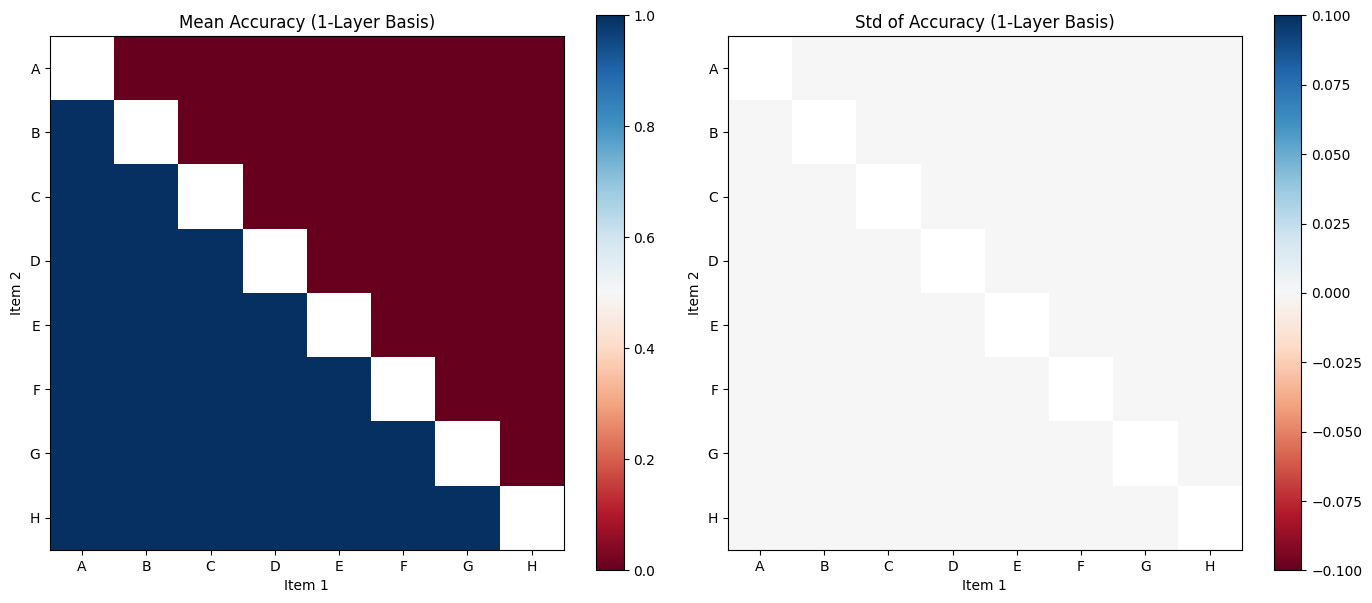

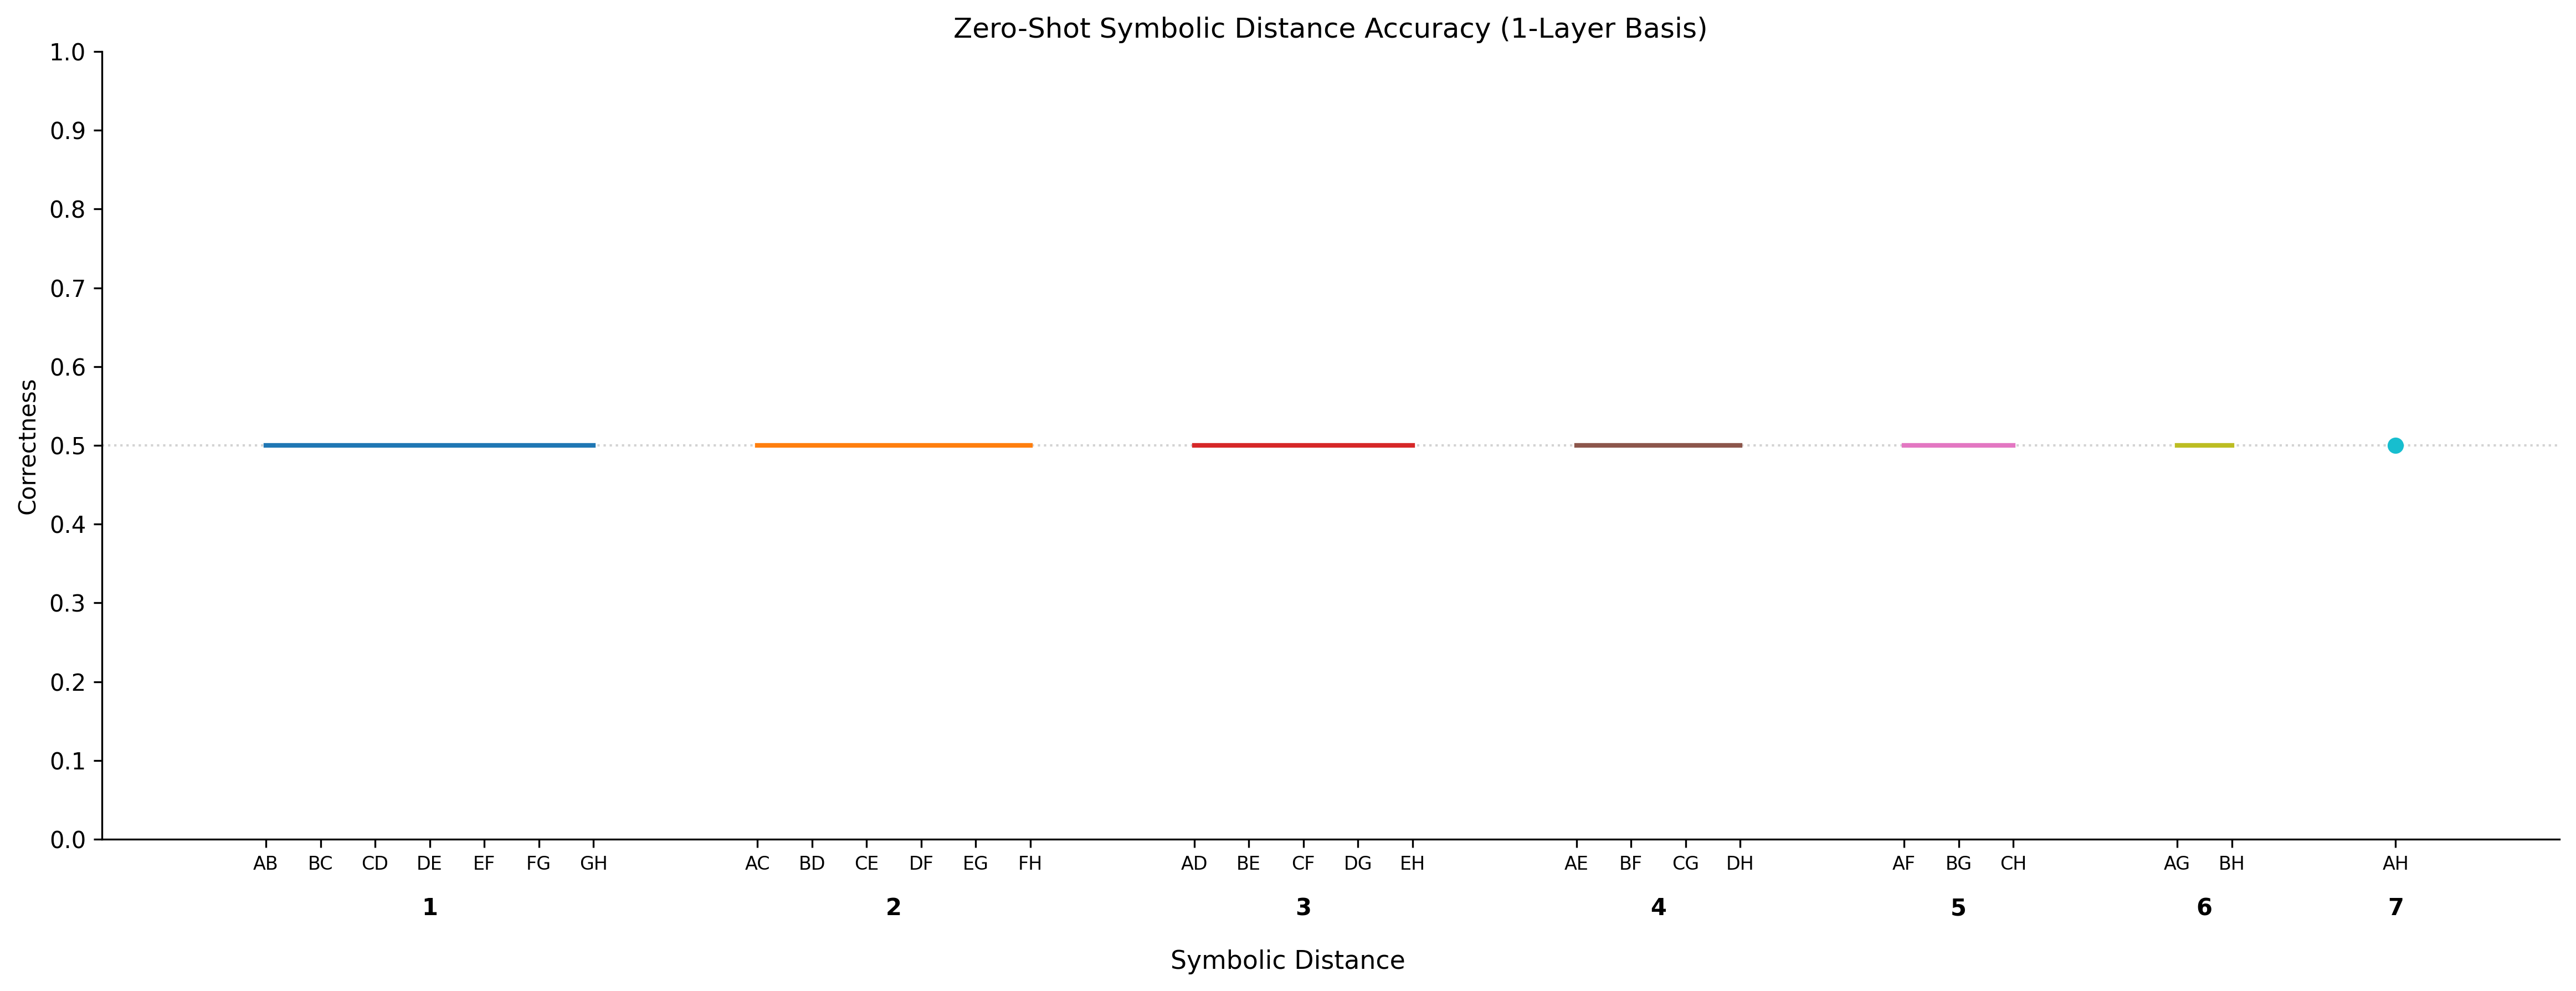

In [173]:
run_1layer_basis(nm_pos=0.0, nm_neg=-2, alpha=0.01, n_episodes=5000,
                     n_items=8, num_train_trials=20, list_linking=False,
                     list_linking_within_list_trials=10, linking_pair_trials=4, use_transform=True, anti_diag_scale=2.0, input_noise_std=0.0, plastic_in_transform=True)